# 2. SuperSubj Level Broadband

## Init

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, pearsonr
import seaborn as sns


In [2]:
from utils import OUT_PATH
from utils import PlotCompoIndividual, BbEvents, GetInfo, CompoThr, ExcludSubj, PolarityCor, computeLagPeak, crosscorr, ConcatPCA, DataTransformationM1, WeightSpearman


epoch_path = OUT_PATH + '/Data_shortWOBS'
epoch_path = 'outs/Data_shortWOBS'
band = 'broadband'

subj_included = [file.replace('_epochs.p', '') for file in os.listdir(epoch_path) if file[-len('epochs.p'):] == 'epochs.p']
subj_included = ExcludSubj(subj_included,  data_path=epoch_path)
print('Number of subject is ', len(subj_included))

#coord, areas, elects, subj = GetInfo(subj_included, data_path=epoch_path)
coords_reg= pd.read_csv('outs/grpPCA/supsubj_concat/high_gamma_labels.csv')
# get the region only for locals
coord = []
for s in subj_included :
    coord_file = pd.read_csv(f'{epoch_path}/{s}_coords.csv')
    coord.extend(np.vstack([coord_file['x'].values,  coord_file['y'].values, coord_file['z'].values]).T)
coord_array = np.array(coord)
regions = coords_reg['region'] 

event_idx = {0: 'Old', 1:'New'}
color_event = {0: 'b', 1:'r'}
interesting_ev= [0,1]


Number of subject is  30


In [3]:
for s in subj_included : 
    path = epoch_path + f'/{s}_info.json'
    with open(path) as json_data:
        d = json.load(json_data)
        time = d['time_epoch']
    break

In [4]:
pol_cor = True
cor_thr = 0.7

## PCA

In [50]:
data = []
subj_list = []
for subj in subj_included: # go over the subject and comptute mean per condi over trials
    data_mean = BbEvents(subj, data_path=epoch_path)
    info_file = f'{epoch_path}/{subj}_info.json'
    data.append(data_mean)
    subj_list.extend([subj] * data_mean.shape[1])

    
data_grp = np.hstack(data)
if pol_cor:
    data_grp = PolarityCor(TFRtr=data_grp, data_path=epoch_path, method_pca='mean', subj_included=subj_included)


In [20]:
# mean option
#data_grp_mean = data_grp.mean(0)
# concat option
data_grp_mean = np.concat([data_grp[i, :, :] for i in [0, 1]], axis =1)

nb_compo = 3
pca = PCA(nb_compo)
pca.fit(data_grp_mean.T)

df_Compo = pd.DataFrame(pca.components_)
df_Compo['compo'] = ['compo'  +str(i+1) for i in range(nb_compo)]
df_Compo['freq'] = ['broadband']*nb_compo 
ev = pca.explained_variance_ratio_
m= pca.mean_[:, None].T

data_transfrom = np.zeros((2, nb_compo, data_grp.shape[2]))
data_transfrom[0, :, :] = pca.transform(data_grp[0, :,:].T-m).T
data_transfrom[1, :, :] = pca.transform(data_grp[1, :,:].T-m).T

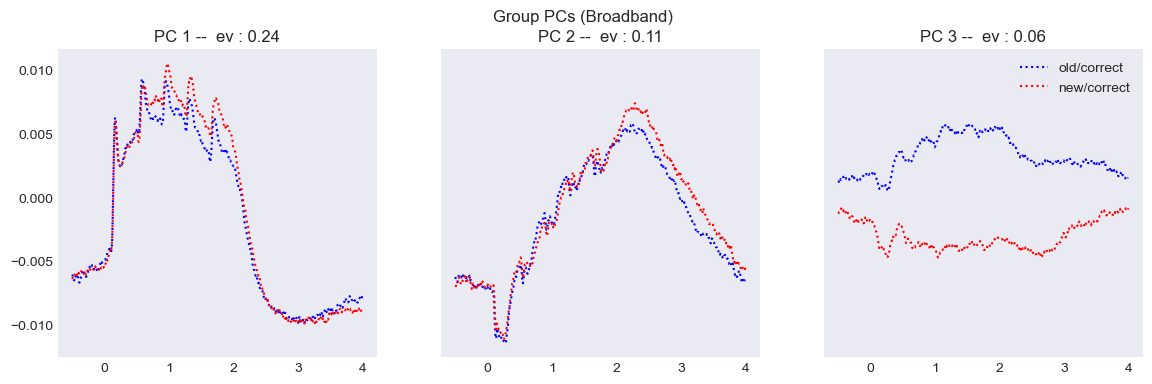

In [22]:
fig, ax = plt.subplots(1, 3, figsize = (14, 4), sharey=True)
fig.suptitle(f'Group PCs (Broadband)')

for i in range(3) : 
    ax[i].plot(time, data_transfrom[0, i,:], c = 'blue', label='old/correct', alpha = 1, ls=':')
    ax[i].plot(time, data_transfrom[1, i,:], c = 'red', label='new/correct', alpha = 1, ls=':')
    ax[i].set_title(f'PC {str(i+1)} --  ev : {np.round(ev[i], 2)}')
ax[i].legend(bbox_to_anchor=(1, 1))
plt.show()

In [29]:
method = 'concat'

if method == 'mean' :
    data_grp_mean = data_grp.mean(0)
else : 
    data_grp_mean = np.concat([data_grp[i, :,:] for i in [0, 1]], axis=1)

nb_compo = 3
pca = PCA(nb_compo)
pca.fit(data_grp_mean.T)

df_Compo = pd.DataFrame(pca.components_)
df_Compo['compo'] = ['compo'  +str(i+1) for i in range(nb_compo)]
df_Compo['freq'] = ['broadband']*nb_compo 
ev = pca.explained_variance_ratio_
m= np.repeat(pca.mean_[None, :], data_grp.shape[2], axis=0)
data_transfrom = np.zeros((2, nb_compo, data_grp.shape[2]))
data_transfrom[0, :, :] = pca.transform(data_grp[0, :,:].T-m).T
data_transfrom[1, :, :] = pca.transform(data_grp[1, :,:].T-m).T

PlotCompoIndividual('grp', 
                    df_Componants={'grp' : df_Compo}, 
                    nb_compo = nb_compo,
                    freq_band=['broadband'], 
                    out_path= OUT_PATH + f'/grpPCA/supsubj_bb_{method}/', 
                    data_path=epoch_path, 
                    show=False)

fig, ax = plt.subplots(1,nb_compo, figsize = (14, 4), sharey=True)
fig.suptitle(f'Group PCs (Broadband)')

for i in range(nb_compo) : 
    ax[i].plot(time, data_transfrom[0, i,:], c = 'blue', label='old/correct', alpha = 0.7)
    ax[i].plot(time, data_transfrom[1, i,:], c = 'red', label='new/correct', alpha = 0.7)
    ax[i].set_title(f'PC {str(i+1)} --  ev : {np.round(ev[i], 2)}')
ax[i].legend()
plt.savefig(OUT_PATH + f'/grpPCA/supsubj_bb_{method}/grp_TimeSeries.png')
plt.close()

# Save
df_X_transform = pd.DataFrame(np.concat([data_transfrom[0, :, :], data_transfrom[1, :, :]], axis=1))
df_X_transform['freq'] = 'broadband'
df_X_transform['subj'] = 'grp'
df_X_transform['compo'] = ['compo' + str(i+1) for i in range(nb_compo)]

df_X_transform.to_csv(f'{OUT_PATH}/grpPCA/supsubj_bb_{method}/grp_Xtrans_PCA{nb_compo}.csv')
df_Compo.to_csv(f'{OUT_PATH}/grpPCA/supsubj_bb_{method}/grp_Compo_PCA{nb_compo}.csv')


## NMF

In [5]:
nb_compo = 4
method_pca = 'mean'

data_mean_list = []
for subj in subj_included: 
    data_mean = BbEvents(subj, data_path=epoch_path)
    data_mean_list.append(data_mean)
    
data_grp = np.hstack(data_mean_list)
if pol_cor : 
    data_grp = PolarityCor(TFRtr=data_grp, data_path=epoch_path, method_pca='mean', subj_included=subj_included)


In [6]:
if method_pca == 'mean' :
    data_grp_mean = data_grp.mean(0)
else : 
    data_grp_mean = np.concat([data_grp[0, :,:], data_grp[1, :,:]], axis=1)

m =data_grp_mean.mean(1, keepdims=True)
df_Componants, df_X_transformed = ConcatPCA({'grp' : data_grp_mean-m}, 
                                            ch_id = False, 
                                            nb_compo =nb_compo, 
                                            freq_band=['broadband'], 
                                            method ='nmf')

In [7]:
weights=df_Componants['grp'].drop(columns= ['compo', 'freq']).values #(4, 2576) compo, electrods

data_transfrom = np.zeros((2, nb_compo, data_grp.shape[2]))
data_transfrom[0, :, :] = weights @ (data_grp[0, :,:] -m)
data_transfrom[1, :, :] = weights @ (data_grp[1, :,:] -m)

df_transform = pd.DataFrame(np.concat([data_transfrom[0, :, :], data_transfrom[1, :, :]], axis = 1))
df_transform['subj'] = 'grp'
df_transform['freq']='broadband'
df_transform['compo'] = ['compo' + str(i) for i in range(nb_compo)]

In [8]:
df_Componants['grp'].to_csv(f'{OUT_PATH}/grpNMF/supsubj_bb_{method_pca}/grp_Compo_NMF{nb_compo}.csv')
df_transform.to_csv(f'{OUT_PATH}/grpNMF/supsubj_bb_{method_pca}/grp_Xtrans_NMF{nb_compo}.csv')

## Correct the polarity

In [22]:
def smooth_moving_average(x, window):
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode='same')

#idx_ref = np.array(df_Compo.drop(columns=['compo', 'freq']).T.nlargest(1, 0).index)
ref = df_X_transform.query("compo == 'compo1'").drop(columns = ['freq', 'subj', 'compo']).values[0, :] 
#signal_ref = data_grp[:, idx_ref[0],  :].mean(0)
signal_ref = (ref[:int(ref.shape[0]/2)] +  ref[int(ref.shape[0]/2):])/2
signal_ref = signal_ref - signal_ref.mean(0)
signal_ref_ = smooth_moving_average(signal_ref[100:600],window=80 )


[Text(0, -0.01, ''),
 Text(0, -0.008, ''),
 Text(0, -0.006, ''),
 Text(0, -0.004, ''),
 Text(0, -0.002, ''),
 Text(0, 0.0, ''),
 Text(0, 0.002, ''),
 Text(0, 0.004, '')]

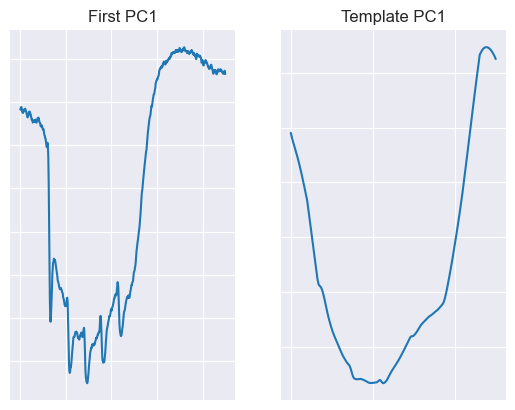

In [23]:
fig, ax = plt.subplots(1,2) 
ax[0].plot(signal_ref)
ax[1].plot(signal_ref_)
ax[0].grid()
ax[1].grid()
ax[0].set_title('First PC1')
ax[1].set_title('Template PC1')
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])


Text(0, 0.5, 'Smallest Channel Weights')

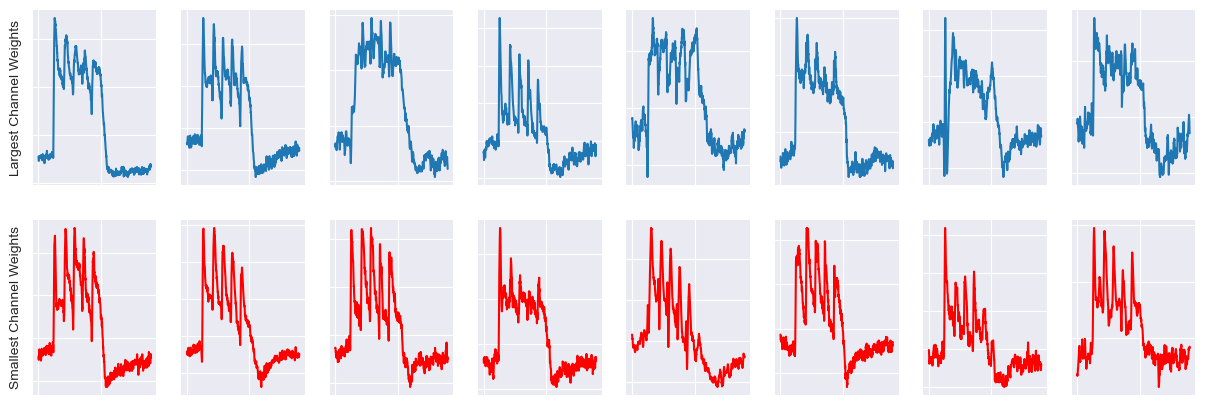

In [26]:
corr =[]
for i_signal in range(data_grp.shape[1]) :
    signal = data_grp[:,i_signal, : ].mean(0)
    signal = signal - signal.mean(0)
    signal = smooth_moving_average(signal[100:600], window=80)
    spe = pearsonr(signal_ref_, signal).statistic # spearmanr(signal_ref_, signal).statistic # out (ch, ch)
    corr.append(spe)

idx_corr_neg = np.where(np.array(corr)>= .7)

# flip 
data_grp_corr = data_grp.copy()
data_grp_corr[:, idx_corr_neg, :] = -1* data_grp[:, idx_corr_neg, :]
idx= np.array(df_Compo.drop(columns=['compo', 'freq']).T.nlargest(8, 0).index)
fig, axs = plt.subplots(2, 8, figsize = (15, 5))
for ax,i in zip(axs[0], idx) : 
    ax.plot(data_grp_corr[0, i, :].T)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid()

axs[0][0].set_ylabel('Largest Channel Weights')

idx= np.array(df_Compo.drop(columns=['compo', 'freq']).T.nsmallest(8, 0).index)
for ax,i in zip(axs[1], idx) : 
    ax.plot(data_grp_corr[0, i, :].T, c='r')
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid()

axs[1][0].set_ylabel('Smallest Channel Weights')


## Explained varriance

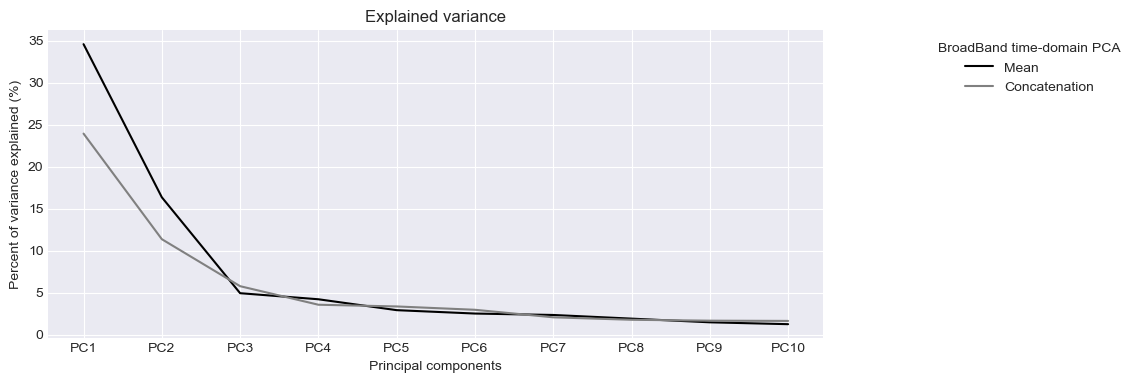

In [48]:
# Get the explain var
colors = plt.get_cmap('tab10')
pca = PCA(10)
pca.fit(data_grp.mean(0).T)

fig, ax= plt.subplots(figsize=(10,4))
ax.plot(['PC'+ str(i) for i in np.arange(10)+1], pca.explained_variance_ratio_*100, c='black', label='Mean')

pca.fit(np.concat([data_grp[0, :,:], data_grp[1, :,:]], axis=1).T)
ax.plot(['PC'+ str(i) for i in np.arange(10)+1], pca.explained_variance_ratio_*100, c='grey', label='Concatenation')
ax.grid()
ax.set_title('Explained variance')
ax.set_xlabel('Principal components')
ax.set_ylabel('Percent of variance explained (%)')
ax.legend(title = 'BroadBand time-domain PCA', bbox_to_anchor=(1.4, 1))
plt.show()



## Analysis

### MEAN vs CONCAT Comparison

In [5]:
method ='nmf'
nb_compo = 4

In [6]:
df_X_transformed_concat =pd.read_csv(OUT_PATH + f'/grp{method.upper()}/supsubj_bb_concat/grp_Xtrans_{method.upper()}{nb_compo}.csv').drop(columns = ['Unnamed: 0'])
df_X_transformed_mean =pd.read_csv(OUT_PATH + f'/grp{method.upper()}/supsubj_bb_mean/grp_Xtrans_{method.upper()}{nb_compo}.csv').drop(columns = ['Unnamed: 0'])

data_concat = df_X_transformed_concat.query('freq == @band').drop(columns = ['compo', 'freq', 'subj']).values
data_mean = df_X_transformed_mean.query('freq == @band').drop(columns = ['compo', 'freq', 'subj']).values

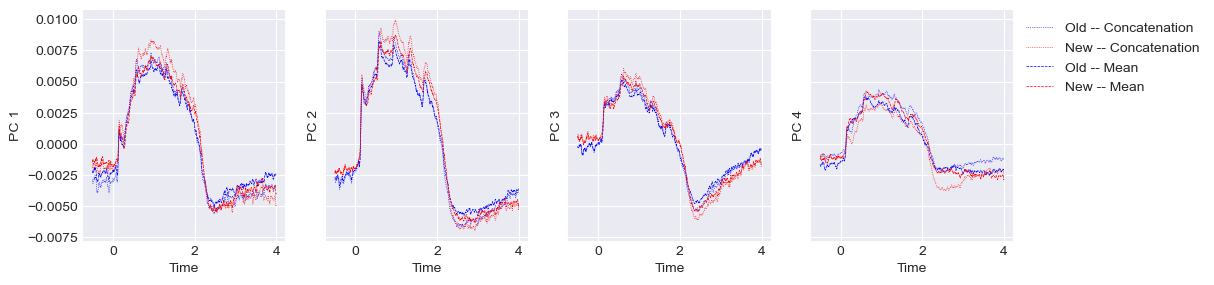

In [7]:
fig, ax = plt.subplots(1,nb_compo, figsize = (3*nb_compo, 3), sharey=True)
for i in range(nb_compo) : 
    ax[i].plot(time, data_concat[i, :int(data_concat.shape[1]/2)], label = f'{event_idx[interesting_ev[0]]} -- Concatenation', ls = ':', c = color_event[interesting_ev[0]], linewidth=0.5)
    ax[i].plot(time, data_concat[i, int(data_concat.shape[1]/2):], label = f'{event_idx[interesting_ev[1]]} -- Concatenation', ls = ':', c= color_event[interesting_ev[1]], linewidth=0.5)
    ax[i].set_ylabel('PC ' + str(i+1))
    ax[i].set_xlabel('Time')
    ax[i].plot(time, data_mean[i, :int(data_mean.shape[1]/2)], label = f'{event_idx[interesting_ev[0]]} -- Mean', ls = '--', c = color_event[interesting_ev[0]], linewidth=0.5)
    ax[i].plot(time, data_mean[i, int(data_mean.shape[1]/2):], label = f'{event_idx[interesting_ev[1]]} -- Mean', ls = '--', c= color_event[interesting_ev[1]], linewidth=0.5)
    ax[i].grid()
ax[-1].legend(bbox_to_anchor = (1, 1))

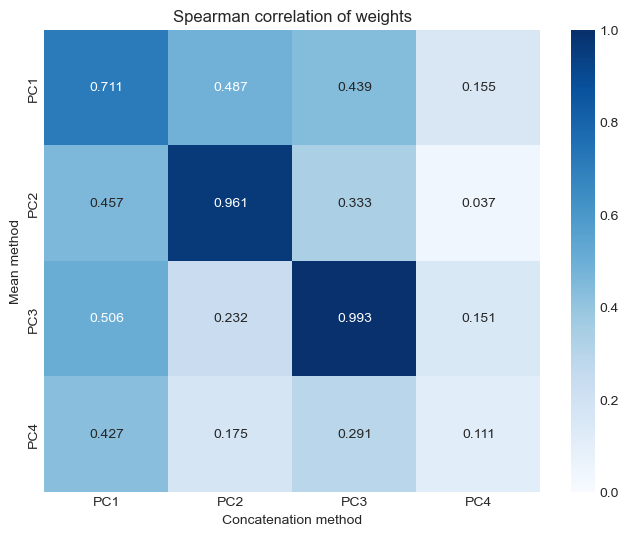

In [11]:
# weights correlation mean vs concat
mean_compo=pd.read_csv(f'{OUT_PATH}/grp{method.upper()}/supsubj_bb_mean/grp_Compo_{method.upper()}4.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
concat_compo=pd.read_csv(f'{OUT_PATH}/grp{method.upper()}/supsubj_bb_concat/grp_Compo_{method.upper()}4.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values

WeightSpearman(mean_compo,concat_compo, labels=['Mean method', 'Concatenation method'])

### Stability across trials

(2, 1, 2576, 900)
(2, 1, 2576, 900)
(2, 1, 2576, 900)


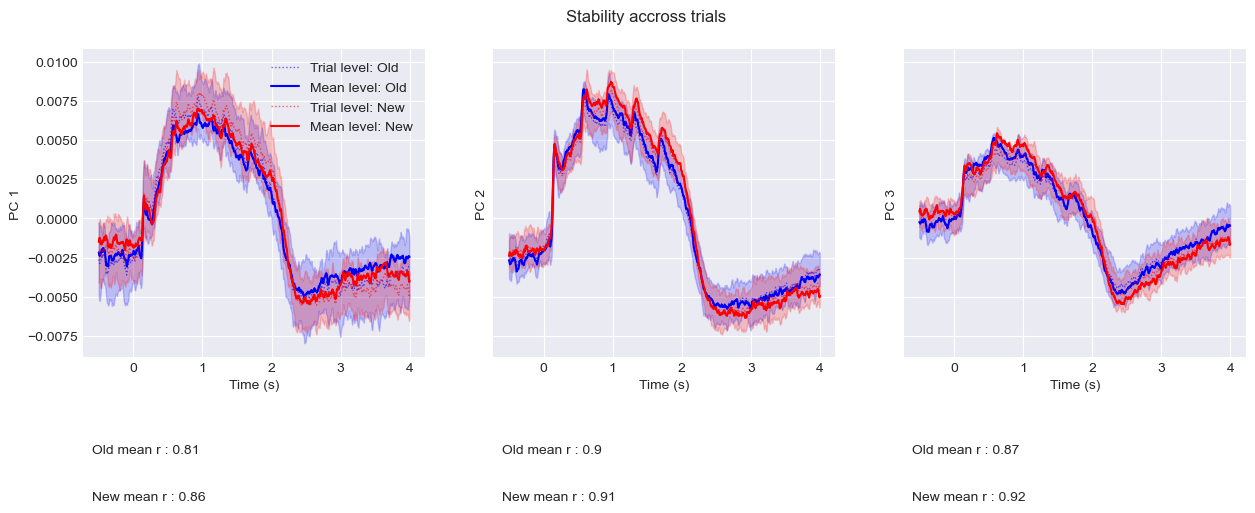

In [5]:
method = 'nmf'
data_aug_method = 'mean'
method_pca = 'mean'
nb_compo = 3
fig, axs= plt.subplots(1,nb_compo , sharey=True, figsize=(15, 4))
fig.suptitle('Stability accross trials')
axs[0].set_ylabel('PC1')
axs[1].set_ylabel('PC2')

color_event = {0: 'b', 1:'r'}
event_idx = {0: 'Old', 1:'New'}

for PC_use in range(nb_compo)  :
    ax = axs[PC_use]
    X_train, y_train, X_test, y_test, True_trials, pca_weights = DataTransformationM1(freq= band, 
                                                                                      method_pca=method_pca, 
                                                                                      data_aug_method=data_aug_method, 
                                                                                      subj_included=subj_included, 
                                                                                      PC_use=PC_use, 
                                                                                      data_path=epoch_path, 
                                                                                      pol_cor=pol_cor, 
                                                                                      method =method)        
    X = np.concat([X_train, X_test])
    y = np.concat([y_train, y_test])
    id_old = np.where(y ==1)[0]
    id_new = np.where(y ==2)[0]

    # Get the group
    df_time_serie = pd.read_csv(OUT_PATH + f'/grp{method.upper()}/supsubj_bb_{method_pca}/grp_Xtrans_{method.upper()}4.csv')
    for col in ['Unnamed: 0', 'subj', 'compo', 'freq', 'error'] : 
        if col in df_time_serie.columns :
            df_time_serie = df_time_serie.drop(columns = col)
    time_serie = df_time_serie.values

    for i_ev,index_  in enumerate([id_old, id_new]) : 
        ax.plot(time, X[index_, :].mean(0), label = f'Trial level: {event_idx[i_ev]}' , c = color_event[i_ev], ls=':', alpha = 0.6, linewidth=1)
        ax.fill_between(time, X[index_, :].mean(0) - X[index_, :].std(0), X[index_, :].mean(0) + X[index_, :].std(0), alpha  = 0.2, color = color_event[i_ev]) 

        if i_ev == 0 :
            ax.plot(time, time_serie[PC_use, :int(time_serie.shape[1]/2)], label = f'Mean level: {event_idx[i_ev]}', c = color_event[i_ev], alpha = 1, ls='-')
        elif i_ev == 1 : 
            ax.plot(time, time_serie[PC_use,  int(time_serie.shape[1]/2):], label = f'Mean level: {event_idx[i_ev]}', c = color_event[i_ev], alpha = 1, ls='-')
        
        corr =np.mean(spearmanr(X[index_, :].T).statistic)
        ax.text(s=f'{event_idx[i_ev]} mean r : {np.round(corr, 2)}', y = -0.015 -i_ev*0.003, x = -0.6)
    
    ax.grid()  
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('PC ' + str(PC_use+1))
    if PC_use == 0 :
        ax.legend()      

### NMF vs PCA

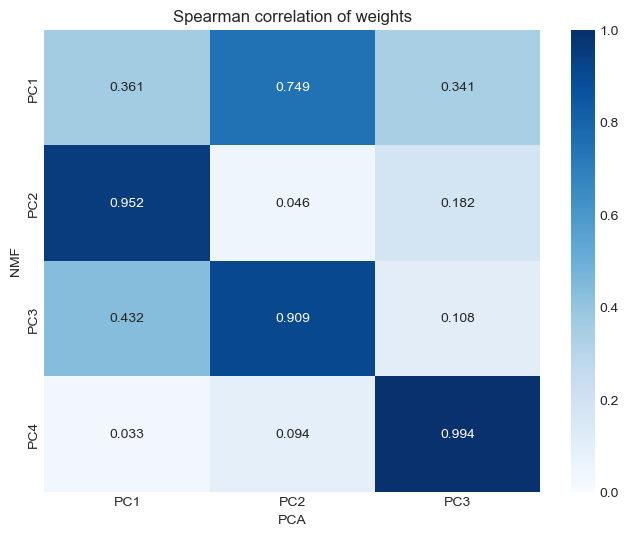

In [6]:
nmf_compo=pd.read_csv(f'{OUT_PATH}/grpNMF/supsubj_bb_concat/grp_Compo_NMF4.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
pca_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_bb_concat/grp_Compo_PCA3.csv').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
WeightSpearman(nmf_compo, pca_compo, ['NMF', 'PCA'])


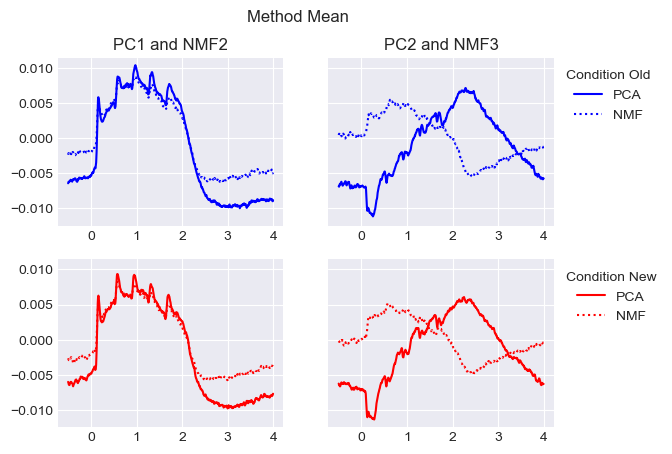

In [7]:
# NMF PC2 AND 3 with PCA PC 1 and 2
df_X_transformed_pca =pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_mean/grp_Xtrans_PCA3.csv')
df_X_transformed_nmf =pd.read_csv(OUT_PATH + f'/grpNMF/supsubj_bb_mean/grp_Xtrans_NMF4.csv')

data_PCA = df_X_transformed_pca.query('freq == @band').drop(columns = ['Unnamed: 0', 'compo', 'freq', 'subj']).values
data_NMF = df_X_transformed_nmf.query('freq == @band').drop(columns = ['Unnamed: 0', 'compo', 'freq', 'subj']).values

fig, axs=plt.subplots(2, 2, sharey=True)
fig.suptitle('Method Mean' )
id_nmf = [1, 2]
id_pca = [0, 1]

for id_nmf_, id_pca_ in zip(id_nmf, id_pca) : 
    axs[1][id_pca_].plot(time, data_PCA[id_pca_, :int(data_PCA.shape[1]/2)], label = 'PCA', c = color_event[1], ls='-')
    axs[1][id_pca_].plot(time, data_NMF[id_nmf_, :int(data_PCA.shape[1]/2)], label ='NMF', c = color_event[1], ls =':')

    axs[0][id_pca_].plot(time, data_PCA[id_pca_, int(data_PCA.shape[1]/2):], label = 'PCA', c = color_event[0], ls='-')
    axs[0][id_pca_].plot(time, data_NMF[id_nmf_, int(data_PCA.shape[1]/2):], label ='NMF', c = color_event[0], ls=':')

    axs[0][id_pca_].set_title('PC' +str(id_pca_+1) + ' and NMF' + str(id_nmf_ +1))
    for i in range(2):
        axs[i][id_pca_].grid()

axs[1][1].legend(title= 'Condition New', bbox_to_anchor = (1, 1))
axs[0][1].legend(title= 'Condition Old', bbox_to_anchor = (1, 1))

### Componants Distribution

In [ ]:
nb_compo = 2
grp_compo=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_bb_concat/grp_Compo_PCA{nb_compo}.csv').drop(columns = 'Unnamed: 0')

data = grp_compo.query("freq == 'broadband'").drop(columns = ['compo', 'freq']).values
data_thr = CompoThr(data, replace = np.nan)
df_data = pd.DataFrame(data_thr.T)
df_data[['x', 'y', 'z']] = np.array(coord)
df_data['region'] = regions
df_data['region'] = df_data['region'].fillna('NON')

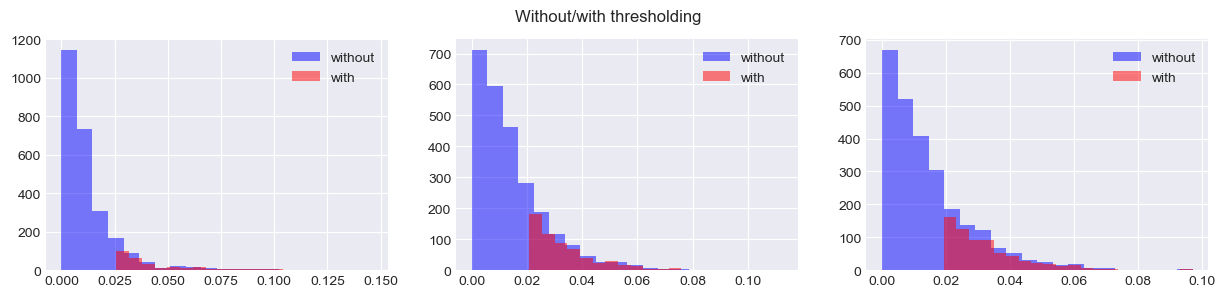

In [25]:
fig, axs = plt.subplots(1, nb_compo, figsize = (15, 3))
fig.suptitle('Without/with thresholding')

df = grp_compo.set_index('compo').drop(columns = ['freq'])
df_thr = df_data[[0, 1, 2]].T
df_thr['compo'] = ['compo' + str(i+1) for i in range(len(df_thr))]
df_thr= df_thr.set_index('compo')

for i, ax in enumerate(axs) : 
    df.loc['compo' + str(i+1), :].apply(lambda x : abs(x)).hist(bins=20, ax=ax, alpha = 0.5, color = 'blue', label = 'without', )
    df_thr.loc['compo' + str(i+1), :].apply(lambda x : abs(x)).hist(bins=20, ax=ax, alpha = 0.5, color = 'red', label='with')   

    ax.legend()

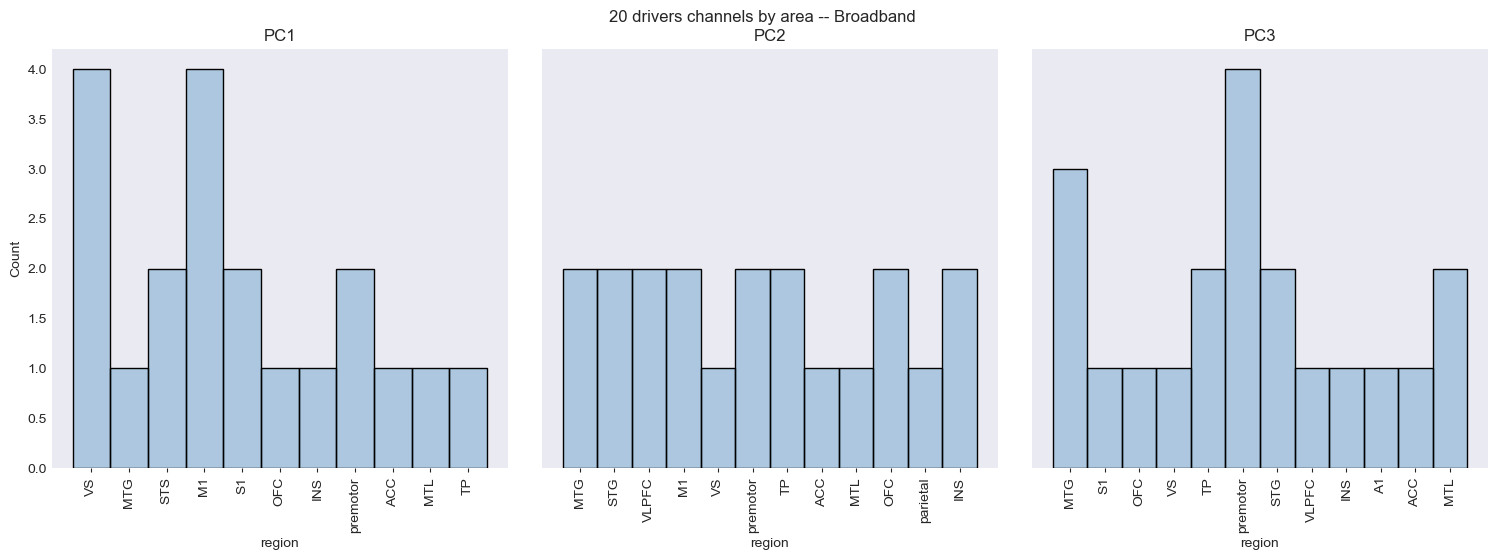

In [26]:
nb_el = 20
largest_list={}
fig, axs = plt.subplots(1, nb_compo, figsize = (5*nb_compo, 5), sharey=True)
fig.suptitle(f'{nb_el} drivers channels by area -- Broadband')
fig.tight_layout()
largest_list = []
for i, ax in enumerate(axs) : 
    largest = df_data.nlargest(nb_el, i)[['region', i]]
    largest_list.append(largest)
    sns.histplot(largest, x= 'region', element='bars', alpha = 0.3, ax=ax)
    ax.tick_params(axis='x', rotation=90, size = 3)
    ax.set_title('PC' + str(i+1))

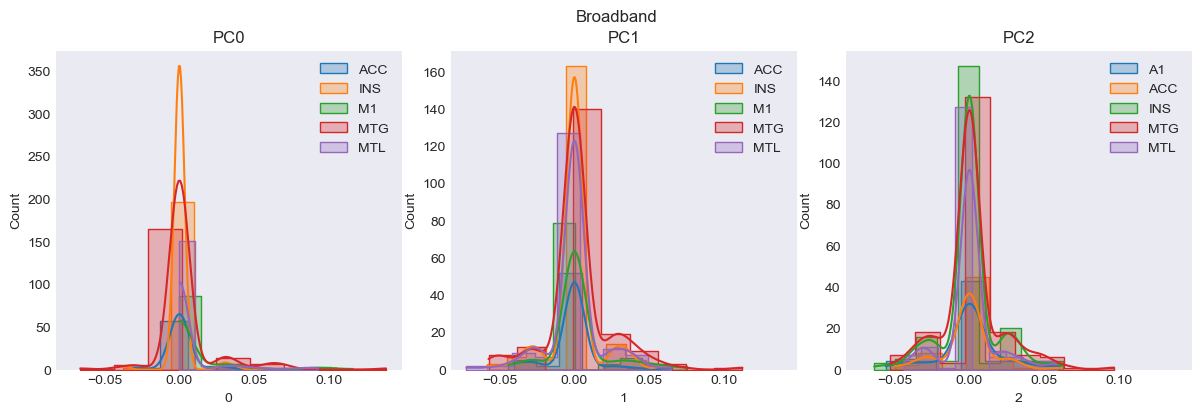

In [27]:
fig, ax = plt.subplots(1, nb_compo, figsize = (nb_compo*4, 4), sharex=True)
fig.suptitle('Broadband')
fig.tight_layout()
df_data = df_data.fillna(0)

for i in range(nb_compo) : 
    area_list_PC = np.unique(largest_list[i].region)
    for r in area_list_PC[:5] :  
        sns.histplot(df_data.set_index('region').loc[r, i], stat='count', element='step', ax= ax[i], kde=True, alpha = 0.3, fill=True, label = r)
    ax[i].set_title('PC' + str(i))
    ax[i].legend()
plt.show()

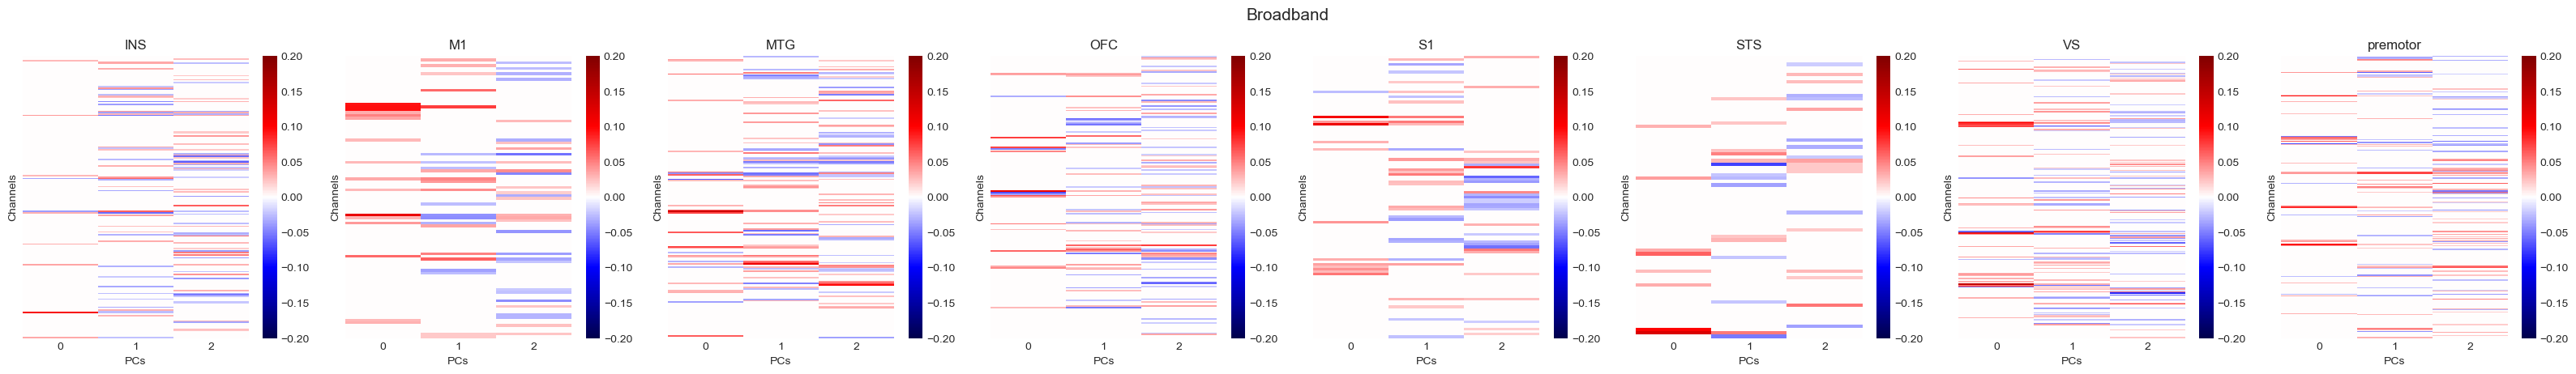

In [28]:
# heatmap of the channels distribution
area_to_check = np.unique(largest_list[0].region[:10])

fig, ax = plt.subplots(1, len(area_to_check), figsize = (len(area_to_check)*4, 4))
fig.tight_layout()
fig.suptitle('Broadband', y= 1.1, size=15)
vlim = 0.2

for i, area_selec in enumerate(area_to_check) :  
    df_subset = df_data[df_data['region'] == area_selec]
    sns.heatmap(df_subset.drop(columns = ['region', 'x', 'y', 'z']),vmin=-0.2, vmax=0.2, center = 0, cmap = 'seismic', ax= ax[i], yticklabels=False)
    ax[i].set_title(area_selec)
    ax[i].set_ylabel('Channels')
    ax[i].set_xlabel('PCs')


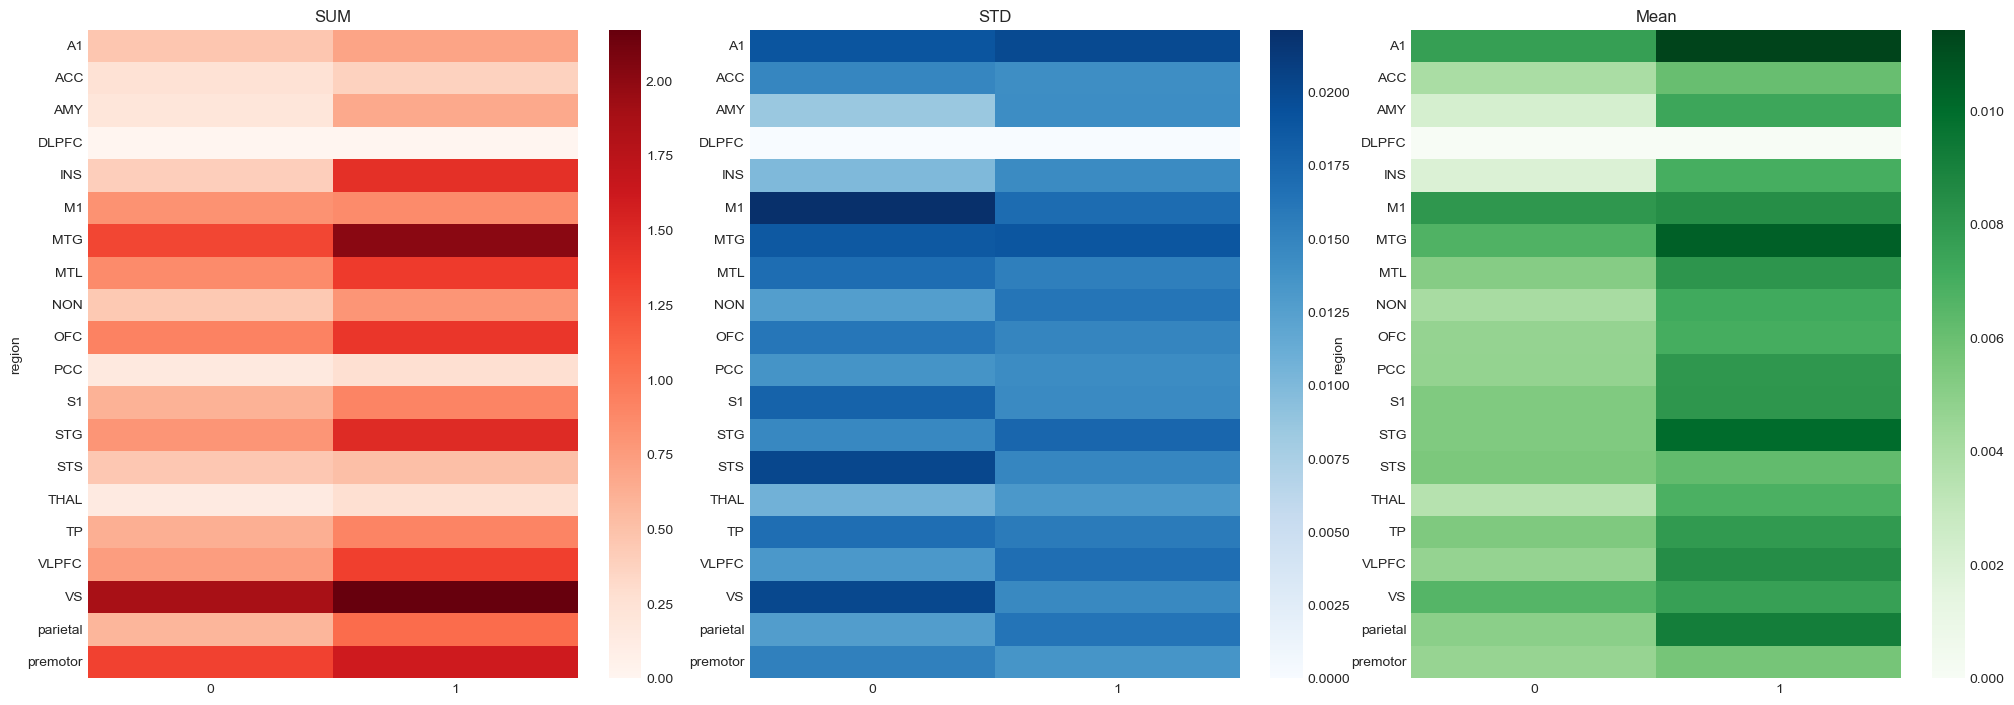

In [29]:
fig, ax = plt.subplots(1, 3, figsize = (20, 7))
fig.tight_layout()
df_data.loc[:, [0, 1, 2]] = df_data.loc[:, [0, 1, 2]].apply(lambda x : np.abs(x))

vlim = np.max(df_data.drop(columns =['x', 'y', 'z', 2]).groupby('region').sum())
sns.heatmap(df_data.drop(columns =['x', 'y', 'z', 2]).groupby('region').sum(), vmin= 0, vmax = vlim, cmap = 'Reds', ax= ax[0], yticklabels=df_data.drop(columns =['x', 'y', 'z']).groupby('region').mean().index)
ax[0].set_title('SUM')

vlim = np.max(df_data.drop(columns =['x', 'y', 'z', 2]).groupby('region').mean())
sns.heatmap(df_data.drop(columns =['x', 'y', 'z', 2]).groupby('region').mean(), vmin= 0, vmax = vlim, cmap = 'Greens', ax= ax[2], yticklabels=df_data.drop(columns =['x', 'y', 'z']).groupby('region').mean().index)
ax[2].set_title('Mean')


vlim = np.max(df_data.drop(columns =['x', 'y', 'z', 2]).groupby('region').std())
sns.heatmap(df_data.drop(columns =['x', 'y', 'z', 2]).groupby('region').std(), vmin= 0, vmax = vlim, cmap = 'Blues', ax= ax[1], yticklabels=df_data.drop(columns =['x', 'y', 'z']).groupby('region').std().index)
ax[1].set_ylabel('')
ax[1].set_title('STD')

plt.show()

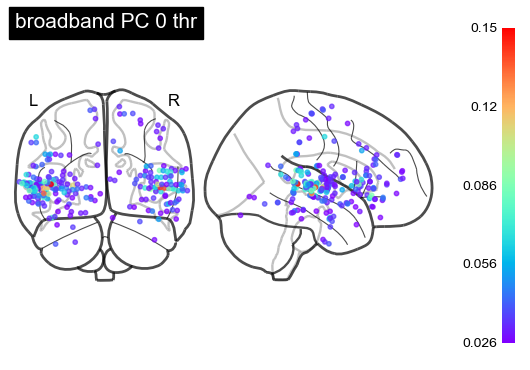

In [31]:
idx= np.where(data_thr[0,:]> 0)
fig = plotting.plot_markers(node_coords = np.array(coord)[idx],  node_size=10, node_values=data_thr[0,idx],
                                node_cmap= 'rainbow', title=band +f' PC 0 thr',display_mode='yx') #, node_vmin=0)


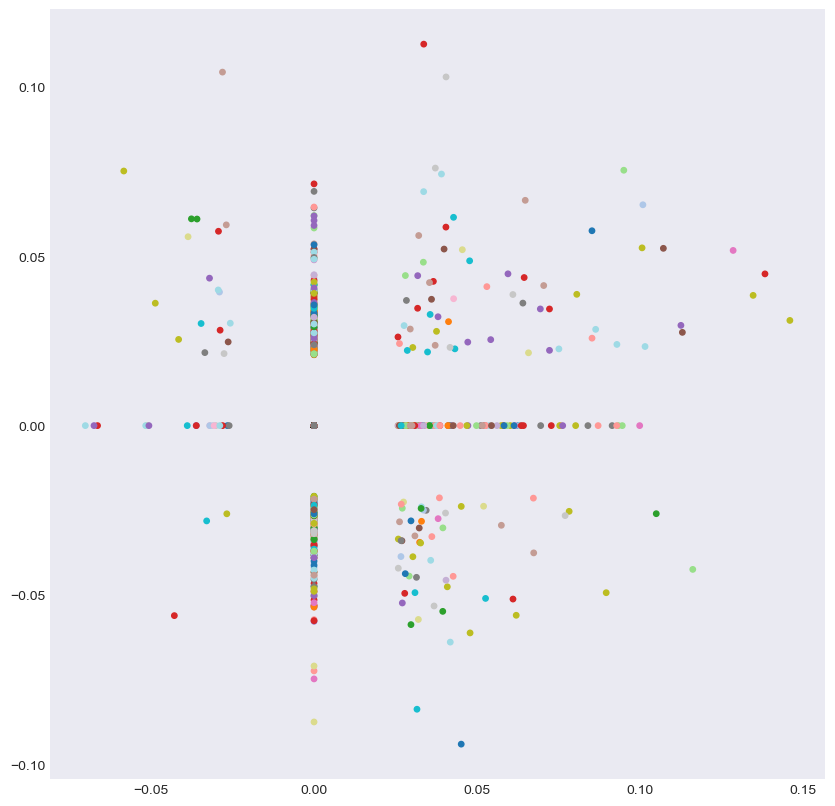

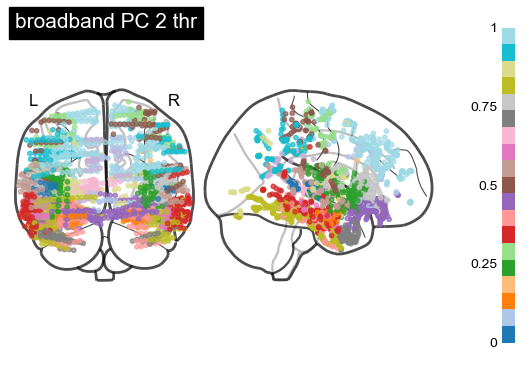

In [63]:
# Binary plot for all the low freq 1 neg wiehgt 2 pos weights
fig, ax =plt.subplots(figsize = (10, 10))
regions_ = [str(r) for r in regions]
unique_r = np.unique(regions_)
mapper = {reg:num for num, reg in zip(np.arange(len(np.unique(regions_))), unique_r)}
region_code = [mapper[r] for r in regions_]
cmap = plt.get_cmap('tab20')
region_code_norm = (region_code - min(region_code))/(max(region_code) - min(region_code)) 
colors = np.array([cmap(code) for code in region_code_norm])

data = grp_compo.query("freq == 'broadband'").drop(columns = ['compo', 'freq']).values
x=0
y=1
data_thr = CompoThr(data, replace=0)
ax.scatter(data_thr[x,:], data_thr[y, :], s=60, marker='.', c=colors,label =band )
fig = plotting.plot_markers(node_coords = np.array(coord),  node_size=10, node_values=region_code_norm,
                                node_cmap= cmap, title=band +f' PC {PC_use+1} thr',display_mode='yx')


### Componant clustering

In [84]:
# run kmean clustering on each freq bar and find the optimal numer of clusters
data = grp_compo.query("freq == 'broadband'").drop(columns = ['compo', 'freq']).values
weight_data_b = CompoThr(data, replace = 0).T

scaler = StandardScaler(with_std=False, with_mean=False)
weight_data_b = scaler.fit_transform(weight_data_b)

silhouette_avg = []
range_n_clusters = np.arange(2, 10)
for n_clusters in range_n_clusters : 
    cl = KMeans(n_clusters)
    cl.fit(weight_data_b)
    cluster_labels = cl.labels_
    silhouette_avg.append(silhouette_score(weight_data_b, cluster_labels))
ncl_best = range_n_clusters[silhouette_avg.index(max(silhouette_avg))]
sil_score = max(silhouette_avg)
kmean = KMeans(ncl_best).fit(weight_data_b)
labels = kmean.labels_.T

Text(0.5, 1.0, 'Broadband -- silhouette score : 0.68')

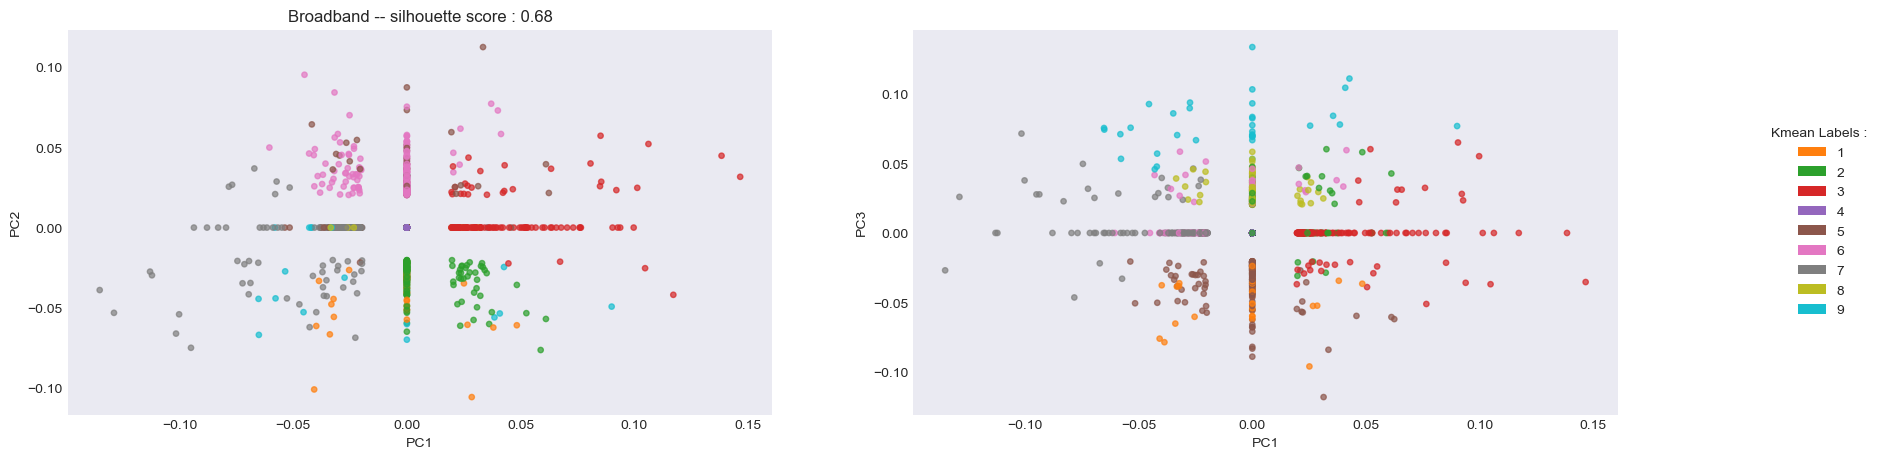

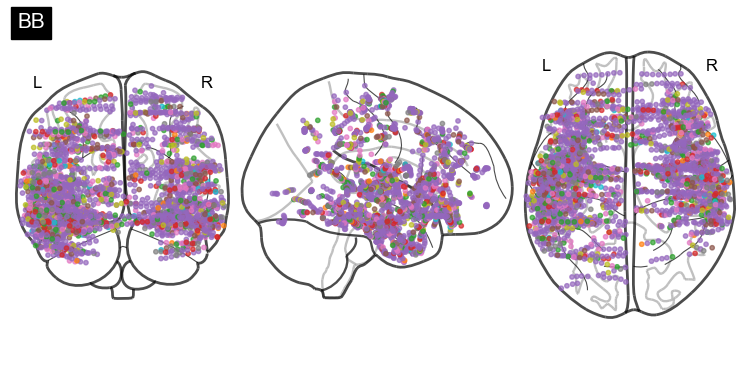

In [89]:
# plot 
base_cmap = plt.cm.tab10  
fig, ax = plt.subplots(1, nb_compo-1, figsize = (20, 5))
weight_data_b_c1 = weight_data_b[:, 0]

idx = np.where(labels >= 1)[0]
colors = [base_cmap(i) for i in np.unique(labels[idx])]
custom_cmap = ListedColormap(colors, name=f'tab20_{len(np.unique(labels[idx]))}')
legend_elements = [Patch(facecolor=custom_cmap(i / len(np.unique(labels))), label=str(lbl)) for i, lbl in enumerate(np.unique(labels))]

for sec_pc in range(nb_compo-1) : 
    weight_data_b_sec = weight_data_b[:,sec_pc +1]
    ax[sec_pc].scatter(weight_data_b_c1,weight_data_b_sec, c= labels, cmap=custom_cmap, alpha=0.7, s=15)
    ax[sec_pc].set_xlabel('PC1')
    ax[sec_pc].set_ylabel('PC' + str(sec_pc+2))

fig = plotting.plot_markers(node_coords=np.array(coord)[idx],node_values=labels[idx],node_size=10,node_cmap=custom_cmap,title='BB',display_mode='ortho', colorbar=False)
ax[sec_pc].legend(handles=legend_elements, title="Kmean Labels : ", bbox_to_anchor=(1.2, 0.5), loc='center left')
ax[0].set_title('Broadband -- silhouette score : ' + str(np.round(sil_score, 2)))

In [90]:
cls_to_try  = np.arange(2, 10)

labels={}
data = grp_compo.query("freq == 'broadband'").drop(columns = ['compo', 'freq']).values
weight_data_b = CompoThr(data, replace = 0).T
scaler = StandardScaler(with_std=False, with_mean=False)
weight_data_b = scaler.fit_transform(weight_data_b)

Z = linkage(weight_data_b, method='ward', metric='euclidean')

# optimize number cluster 
silhouette_scores = []
for k in cls_to_try:
    l = fcluster(Z, k, criterion='maxclust')
    sil = silhouette_score(weight_data_b, l)
    silhouette_scores.append(sil)

k = cls_to_try[silhouette_scores.index(max(silhouette_scores))]
labels = fcluster(Z, k, criterion='maxclust')


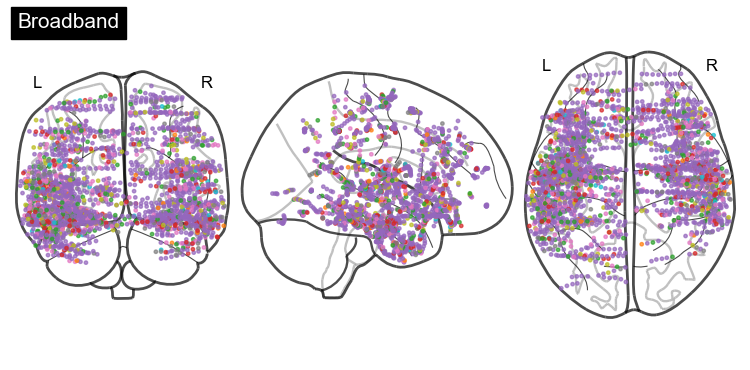

In [91]:
idx = np.where(labels !=5 )[0]
colors_w0 = [base_cmap(i) for i in np.unique(labels)]
custom_cmap_w0 = ListedColormap(colors_w0, name=f'tab20_{len(np.unique(labels))}')
fig = plotting.plot_markers(node_coords=np.array(coord)[idx],node_values=labels[idx],node_size=6,node_cmap=custom_cmap_w0,title='Broadband',display_mode='ortho', colorbar=False)


### LAGS between compo 1 and compo 2

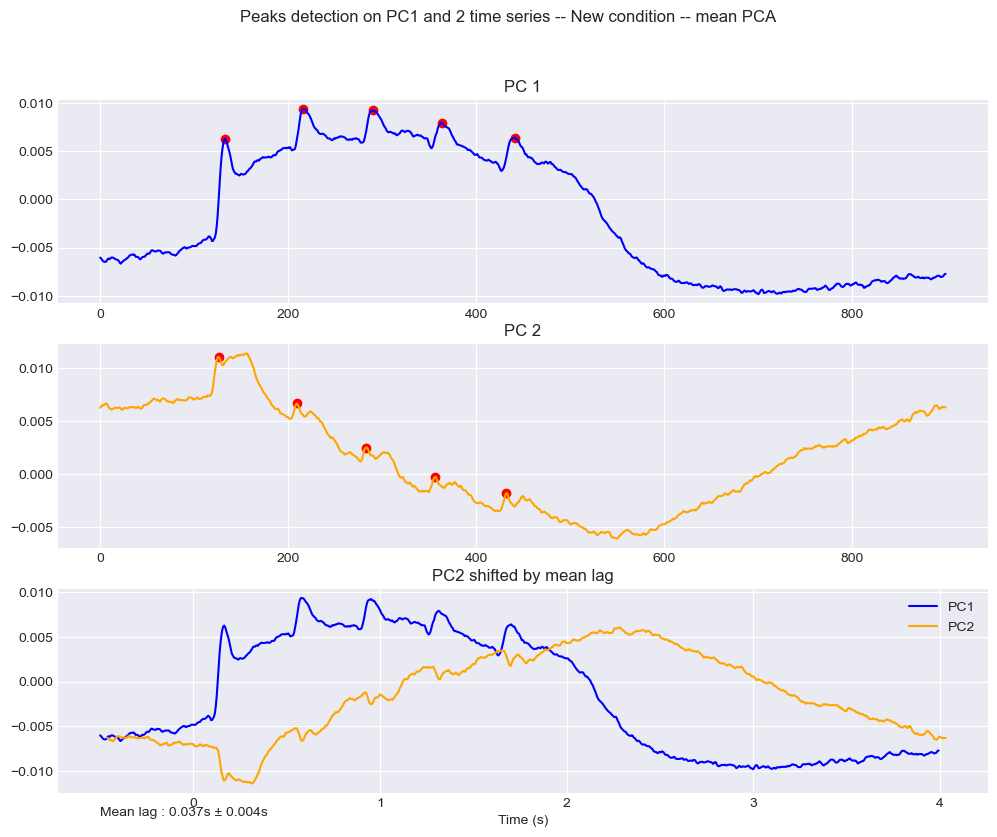

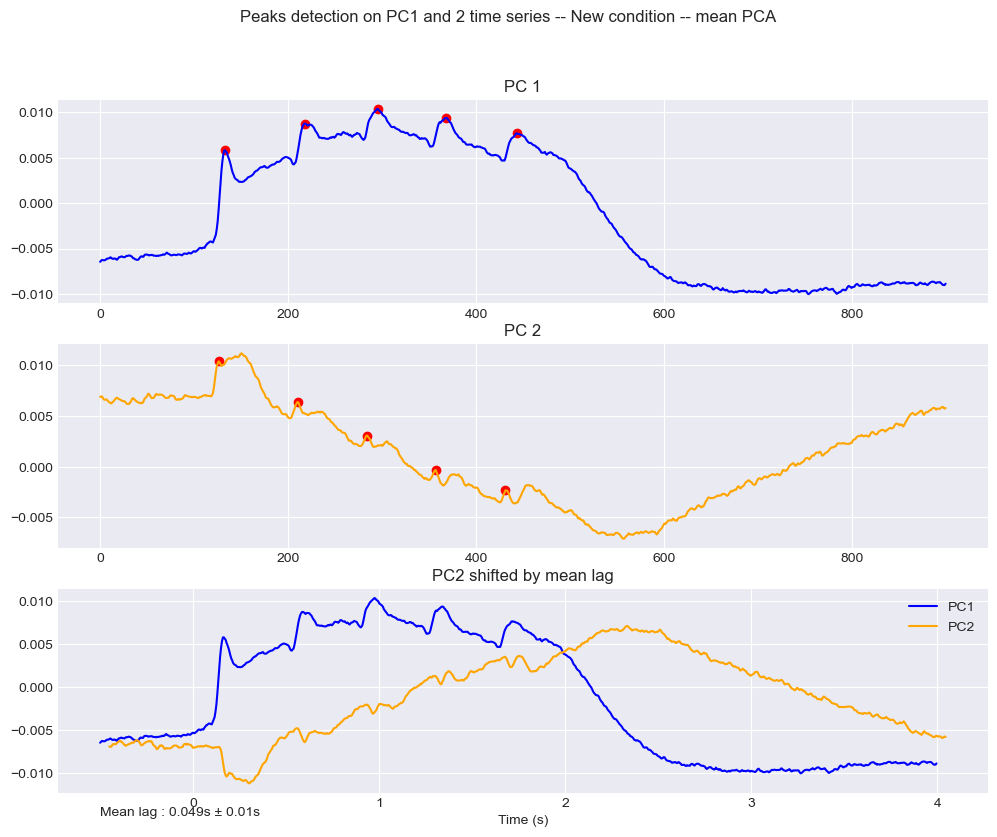

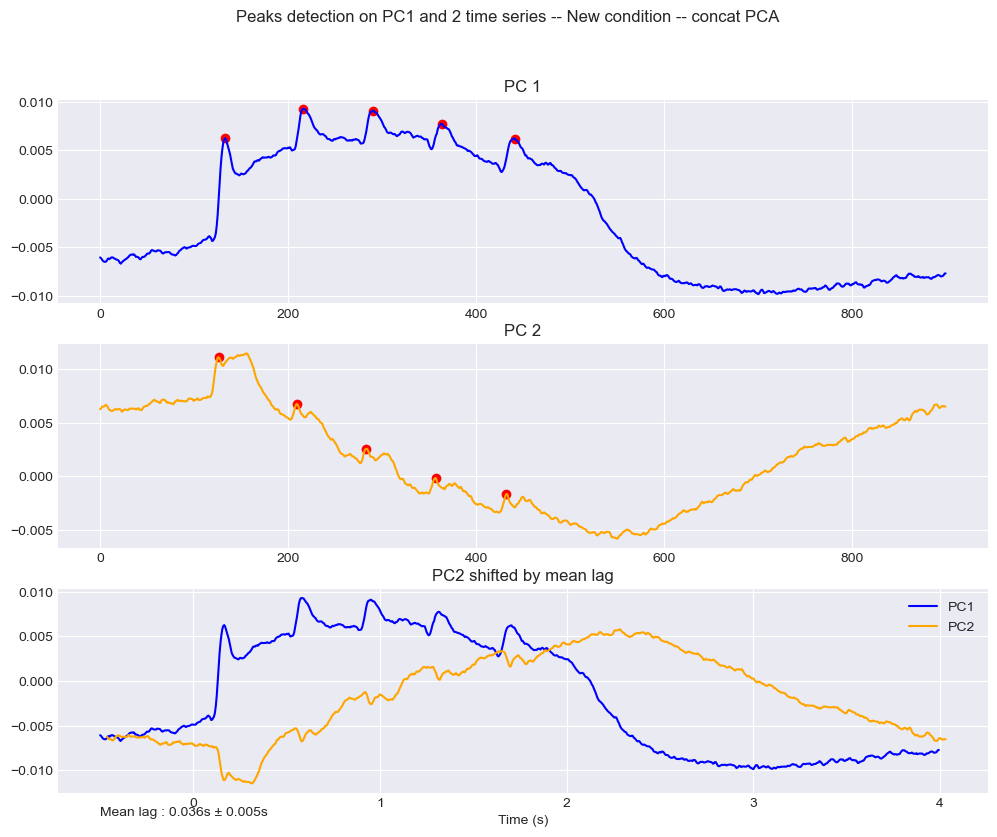

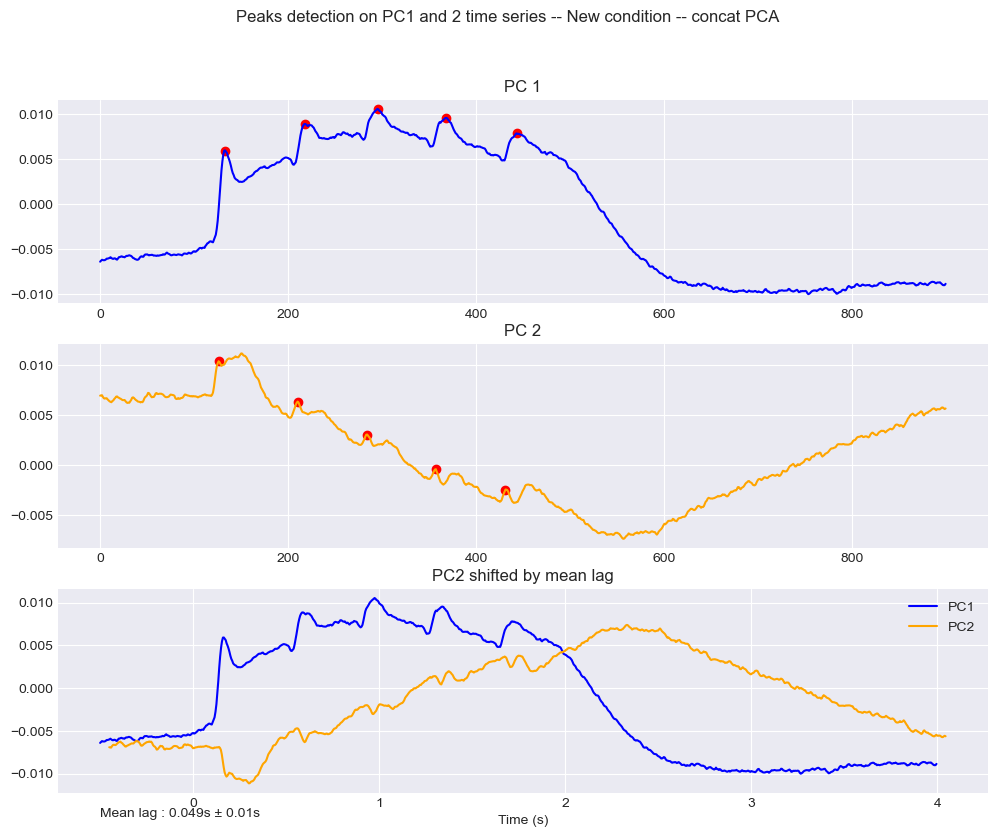

In [ ]:
lag_dict={'mean_old':[], 'mean_new':[], 'concat_old':[], 'concat_new':[]}

for pca_method in ['mean', 'concat'] :
    data= pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_{pca_method}/grp_Xtrans_PCA3.csv').query('freq == "broadband"').drop(columns = ['Unnamed: 0', 'freq', 'compo', 'subj']).values #, 'expl_var']).values
    data = np.concat([[data[:, :int(data.shape[1]/2)]], [data[:, int(data.shape[1]/2):]]], axis=0)
    for i_condi, condi in enumerate(['old', 'new']) : 
        coni = pd.DataFrame(data[i_condi, :,:].T).T

        if condi == 'new' :
            win_high = {0 : [([100, 180], 0.005), ([200, 400], 0.006), ([400, 600], 0.005)], 
            1: [([100, 130], 0), ([200, 450], -0.005)]}
        elif condi == 'old' :
            win_high = {0 : [([100, 180], 0.005), ([200, 400], 0.006), ([400, 600], 0.005)], 
            1: [([100, 130], 0), ([200, 450], -0.005)]}
        # reverse compo2 
         lag = computeLagPeak(coni.values, time, win_high, method_pca=pca_method, show=True, dis=60)
        lag_dict[f'{pca_method}_{condi}'].extend(lag)


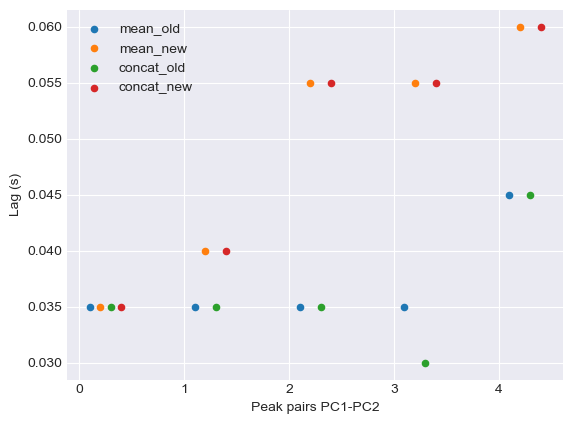

In [6]:
y= np.linspace(0, 4, 5)
for key, values in lag_dict.items():
    y += 0.1
    plt.scatter(x=y, y=values, label=key, s=20)
plt.ylabel('Lag (s)')
plt.xlabel('Peak pairs PC1-PC2')
plt.legend()
plt.grid()

In [8]:
# trial level 
method_pca ='mean'
data_aug_method = 'mean'
method ='pca'
X_train, y_train, X_test, y_test, True_trials, pca_weights = DataTransformationM1(freq= band, 
                                                                                      method_pca=method_pca, 
                                                                                      data_aug_method=data_aug_method, 
                                                                                      subj_included=subj_included, 
                                                                                      PC_use=0, 
                                                                                      data_path=epoch_path, 
                                                                                      pol_cor=pol_cor, 
                                                                                      method =method)        
X_0= np.concat([X_train, X_test])
y_0 = np.concat([y_train, y_test])

X_train, y_train, X_test, y_test, True_trials, pca_weights = DataTransformationM1(freq= band, 
                                                                                      method_pca=method_pca, 
                                                                                      data_aug_method=data_aug_method, 
                                                                                      subj_included=subj_included, 
                                                                                      PC_use=1, 
                                                                                      data_path=epoch_path, 
                                                                                      pol_cor=pol_cor, 
                                                                                      method =method)        
X_1 = np.concat([X_train, X_test])
y_1 = np.concat([y_train, y_test])

In [ ]:
np.vstack([[X_0[idx0, :]], [X_1[idx1, :]]])

(2, 48, 900)

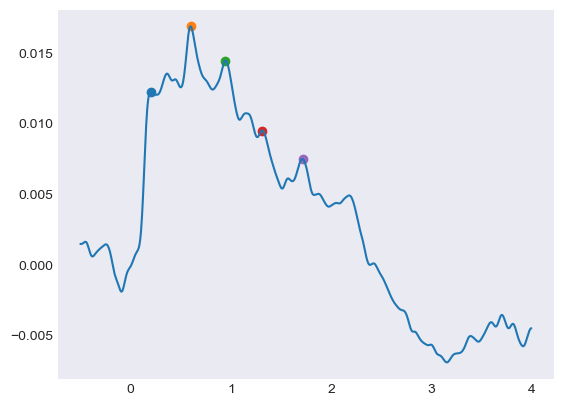

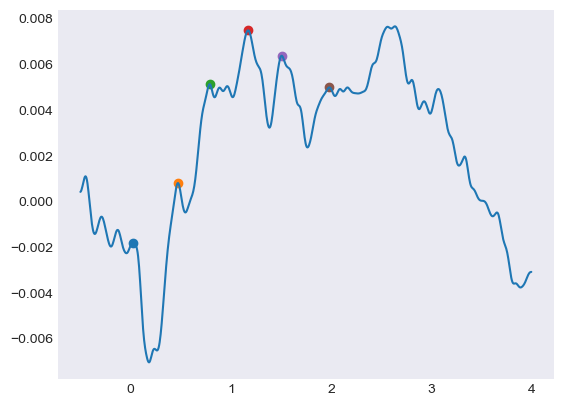

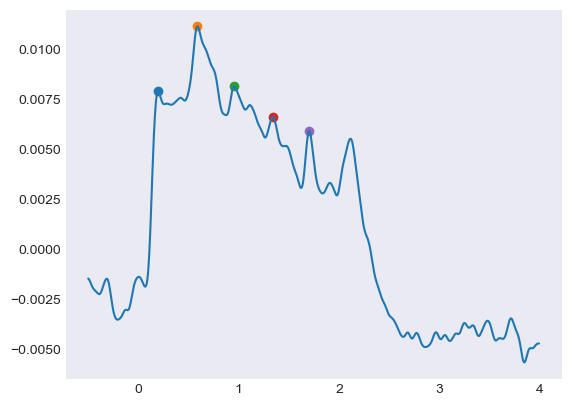

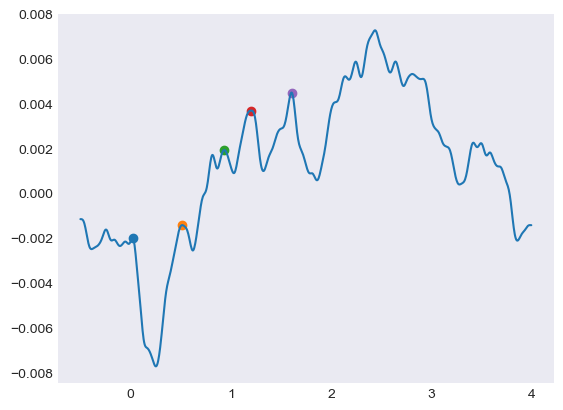

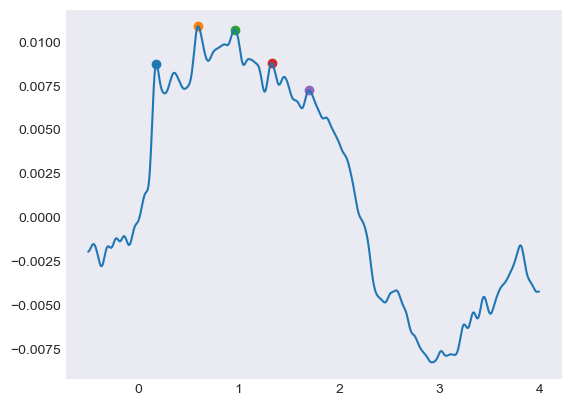

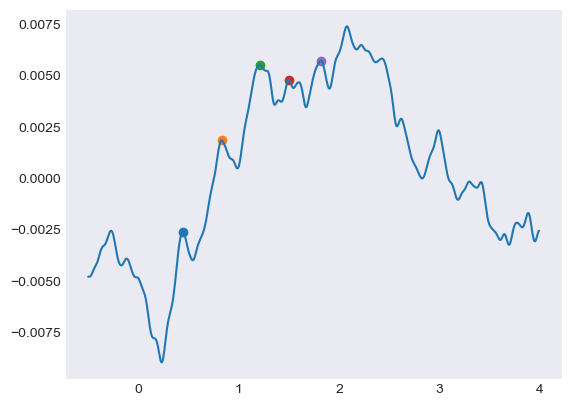

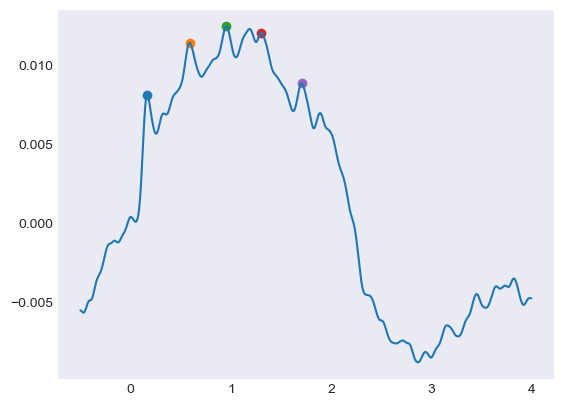

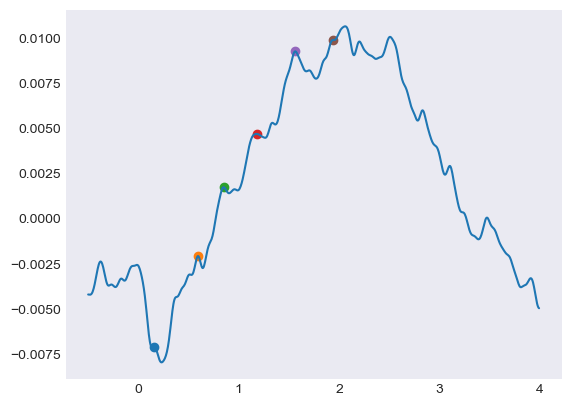

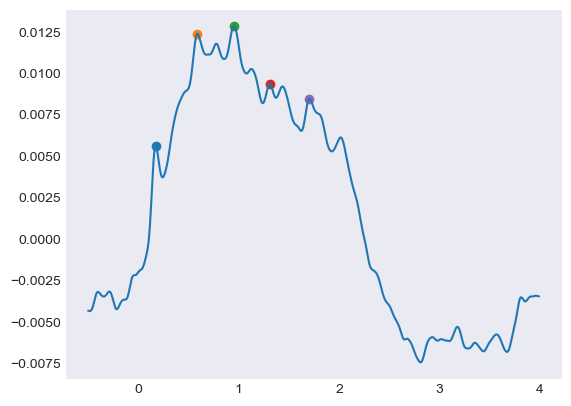

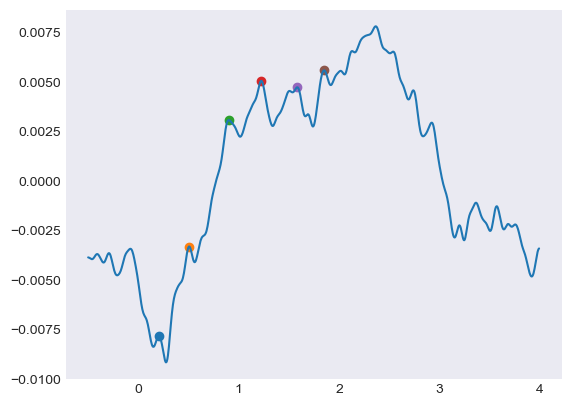

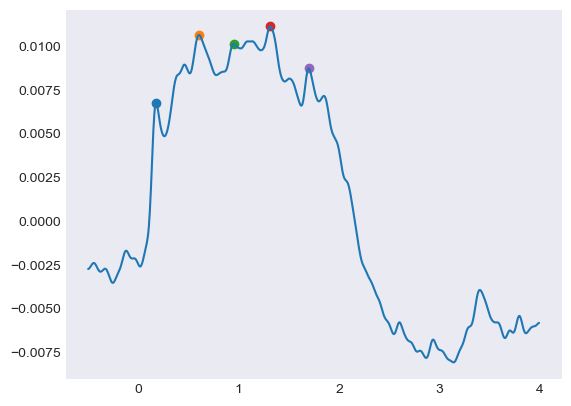

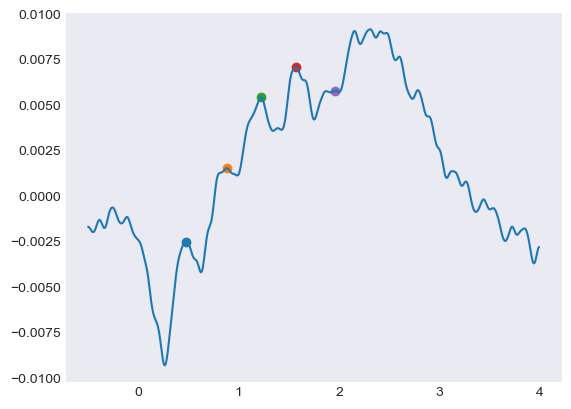

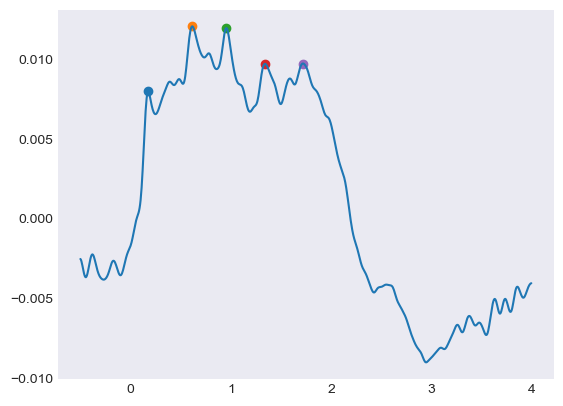

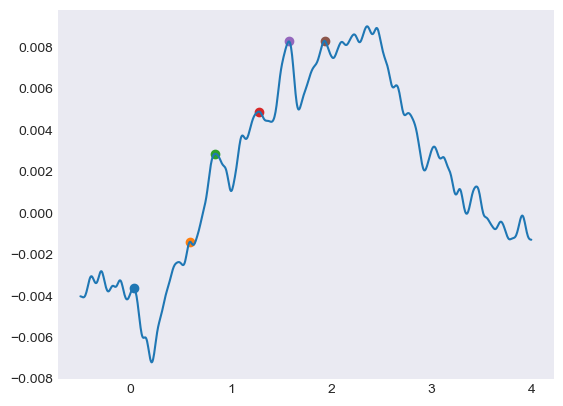

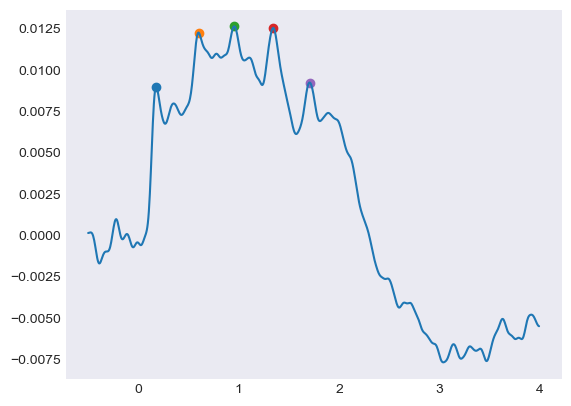

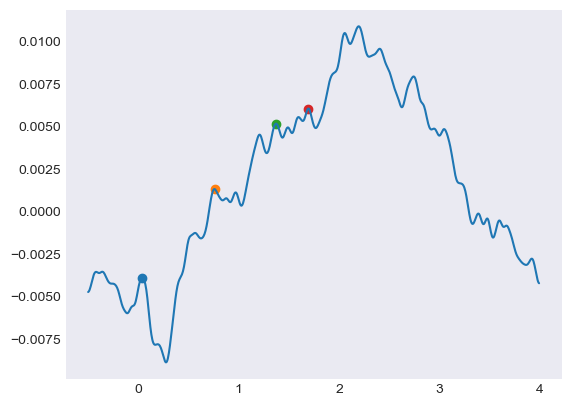

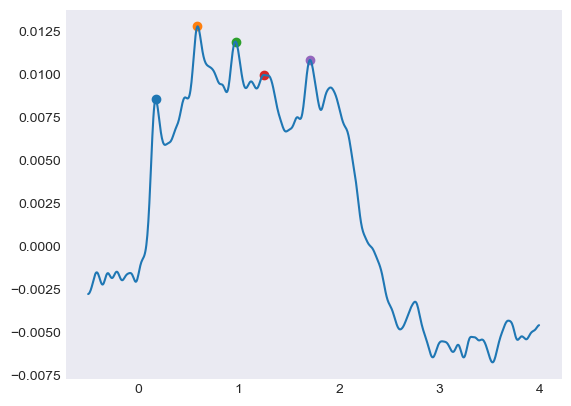

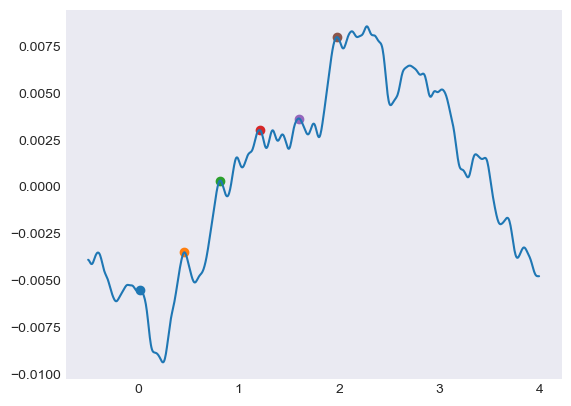

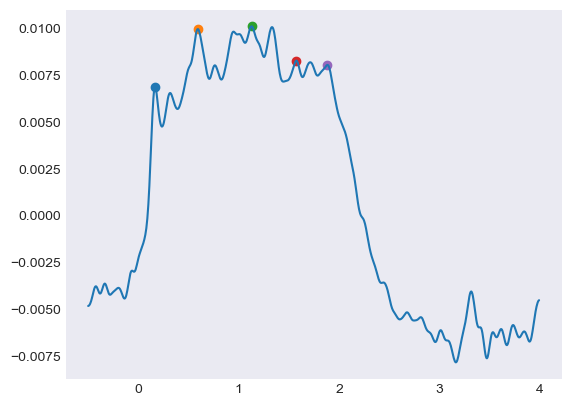

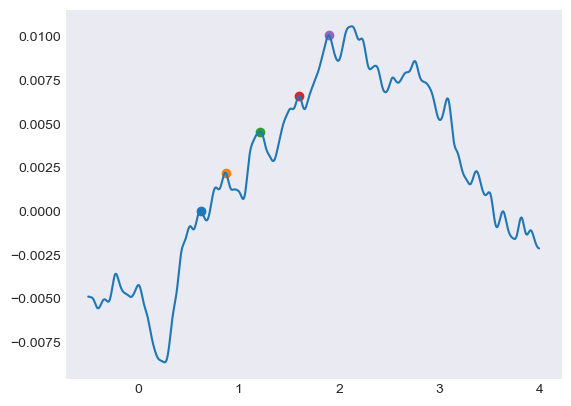

In [69]:
# Detecting peaks
from scipy.signal import find_peaks


lags = []
condi = 'new'
id_condi = 1
win_high = {0 : [([100, 200], 0.0070), ([200, 400], 0.0090), ([400, 600], 0.009)], 
            1: [([100, 130], 0.0075), ([200, 400], -1), ([400, 450], -0.0045)]}
peaks_commpo = {0 :[], 1:[]}
X = np.vstack([[X_0[np.where(y_0 == id_condi)[0], :]], [X_1[np.where(y_1 == id_condi)[0], :]]])
from scipy.ndimage import gaussian_filter1d

for tr in range(X.shape[1]) : #iterate over the trials to built distribution
    for c in range(X.shape[0]) : # throug componant
        X_s = gaussian_filter1d(X[c,tr,:], sigma=5)
        peaks, _ = find_peaks(X_s[time.index(0):time.index(2)], distance=50)
        
        if tr < 10: 
            plt.plot(time, X_s)
            for p in peaks:
                plt.scatter(time[p+time.index(0)], X_s[p+time.index(0)])
            plt.show()
        #for win, high in win_high[c] : # iterate over the 3 peaks
            #peaks, _ = find_peaks(X[c,tr, win[0]:win[1]], height=high, distance=150)
            #peaks_commpo[c].append([p + win[0] for p in peaks])

        

Text(0.5, 1.0, 'Max corss correlation between componant : lag = -0.05499999999999999')

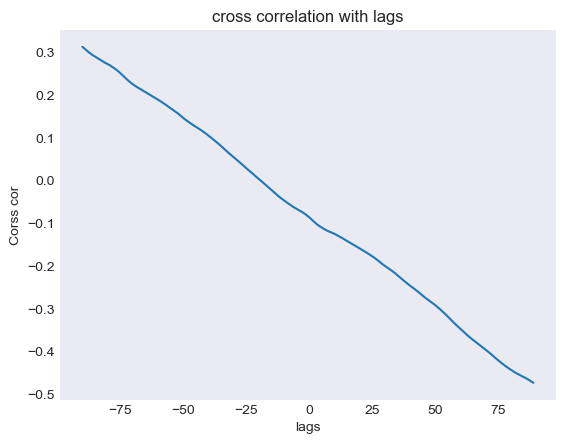

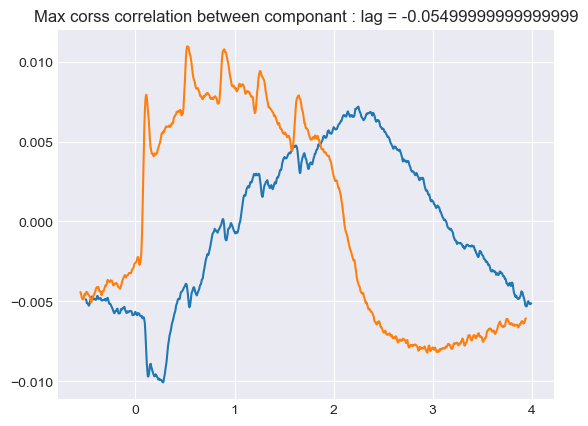

In [ ]:
cc = []
lags = np.arange(int(-180/2), int(180/2))

for l in lags : 
    cc.append(crosscorr(coni1[0], coni1[1], lag=l))

plt.plot(lags, cc)
plt.title('cross correlation with lags')
plt.ylabel('Corss cor')
plt.xlabel('lags')

cc = [abs(c) for c in cc]

fig, ax = plt.subplots()
ax.plot(time , coni1[1])
ax.plot(np.array(time) + time[lags[cc.index(max(cc))]] , coni1[0])
ax.grid()
plt.title(f'Max corss correlation between componant : lag = {time[lags[cc.index(max(cc))]]}')

### from grp to subj

To test whether these components generalize to individual subjects despite heterogeneous electrode montages, we quantified 
- variance explained within each subject’s electrode block, 
- cross-subject correlation of component time series,  
- leave-one-subject-out component stability.


In [42]:
from utils import subject_variance_explained, loso_pca_stability, intersubject_correlation

In [55]:
#data_grp_ = data_grp.mean(0)
data_grp_ = np.concat([data_grp[i, :, :] for i in [0, 1]], axis =1)

pca = PCA(3)
pca.fit(data_grp_.T)
W = pca.components_

r2 = subject_variance_explained(data_grp_, subj_list, W.T, data_path=epoch_path)
print('R2 mean:', r2.mean()*100)

stability = loso_pca_stability(data_grp_, subj_list, 3, data_path=epoch_path)
print("Mean LOSO stability:", stability.mean(axis=0))

for k in range(3):
    mean_r, all_r = intersubject_correlation(data_grp_, subj_list, W, k, data_path=epoch_path)
    print(f'PC{k+1}: Mean inter-subject correlation: {mean_r}') 


KeyboardInterrupt: 

In [163]:
# Compo analysis 
nb_compo=3
method_pca = 'mean'
grp_TS=pd.read_csv(f'{OUT_PATH}/grpPCA/supsubj_bb_{method_pca}/grp_Xtrans_PCA{nb_compo}.csv').drop(columns = 'Unnamed: 0')
subj_TS=pd.read_csv(f'{OUT_PATH}/subjPCA/Broadband/subj_Xtrans_PCA{nb_compo}_{method_pca}.csv').drop(columns = 'Unnamed: 0')

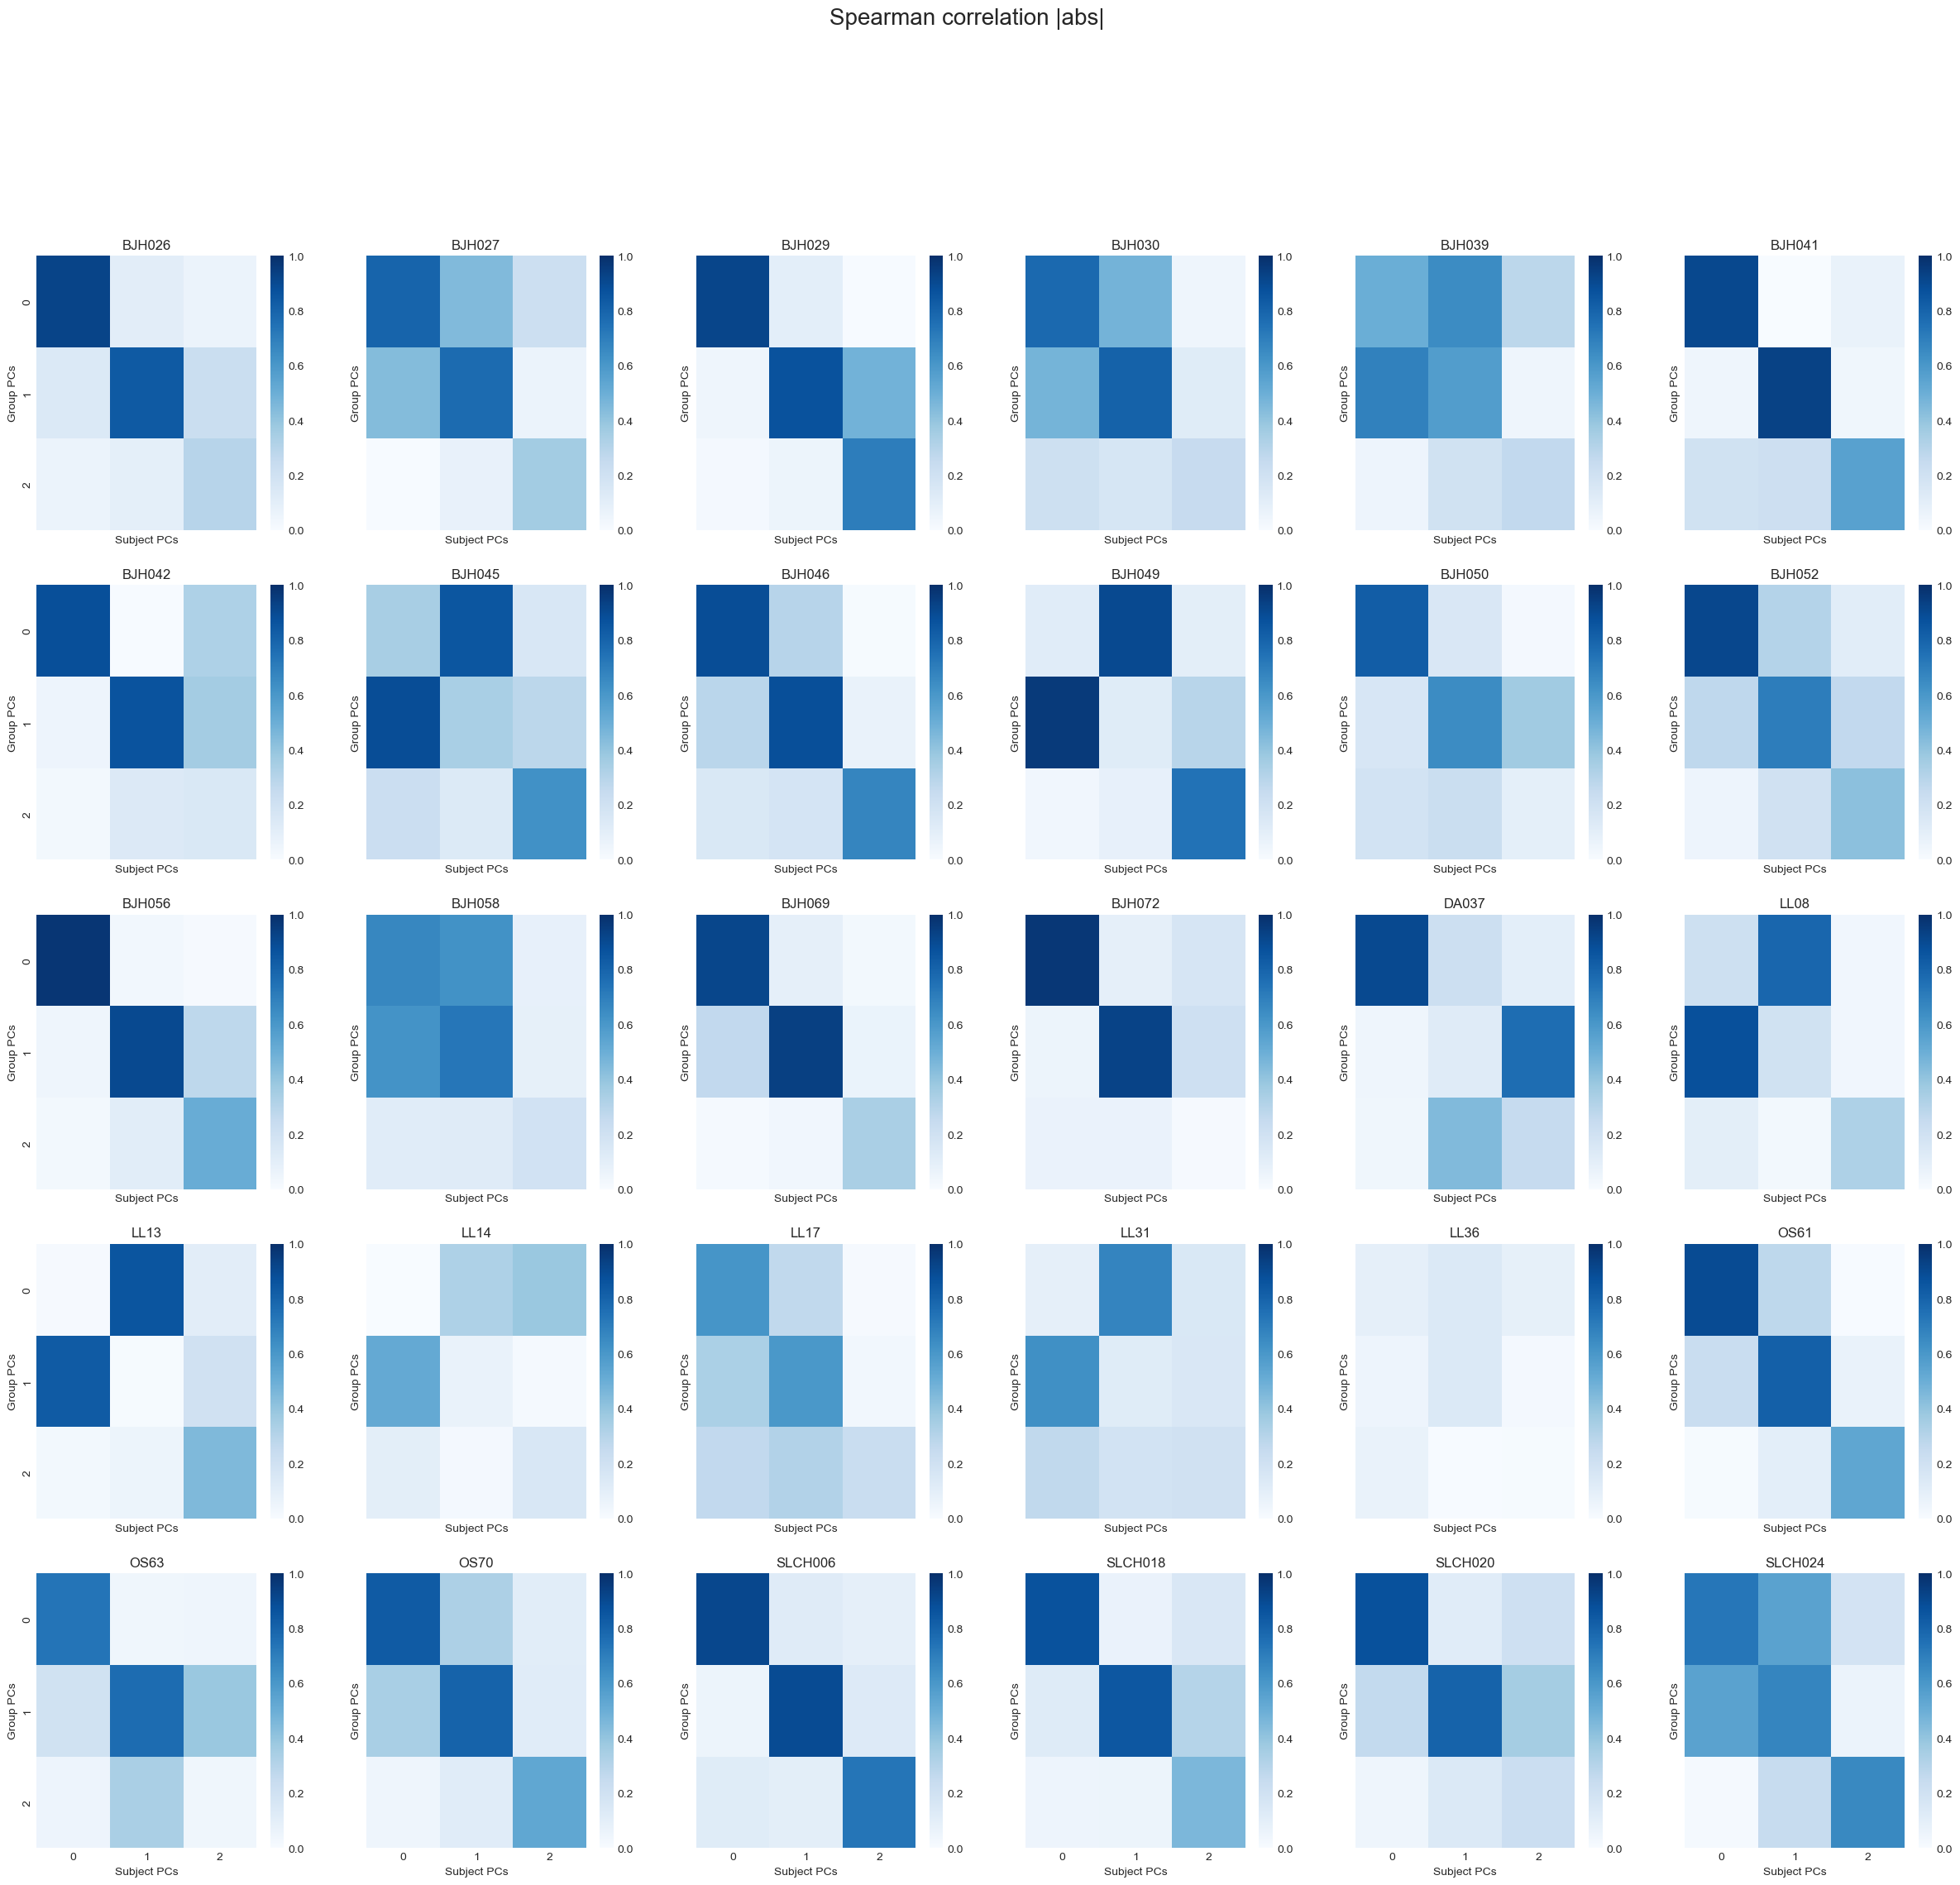

In [164]:
# Correlation table
row_nb = len(np.unique(subj_TS.subj))%5
if row_nb == 0 : row_nb = 5 
col_nb = int(len(np.unique(subj_TS.subj))/5)
if col_nb == 0 : col_nb=1

fig, ax = plt.subplots(row_nb,col_nb, sharey=True, sharex=True, figsize = (col_nb*5, row_nb*5))
fig.suptitle('Spearman correlation |abs|', y=1., size = 20)

index_col = grp_TS.columns[-4]

for a, subj in zip(ax.flatten(), np.unique(subj_TS.subj)) : 
    subj_df = subj_TS.query('subj == @subj')
    corr= spearmanr(grp_TS.loc[:, :index_col].T, subj_df.loc[:, :index_col].T)[0][:nb_compo, nb_compo:nb_compo*2]
    sns.heatmap(abs(corr), ax=a, cmap='Blues', vmax = 1, vmin= 0)
    a.set_xlabel('Subject PCs')
    a.set_ylabel('Group PCs')
    a.set_title(subj)
plt.show() 

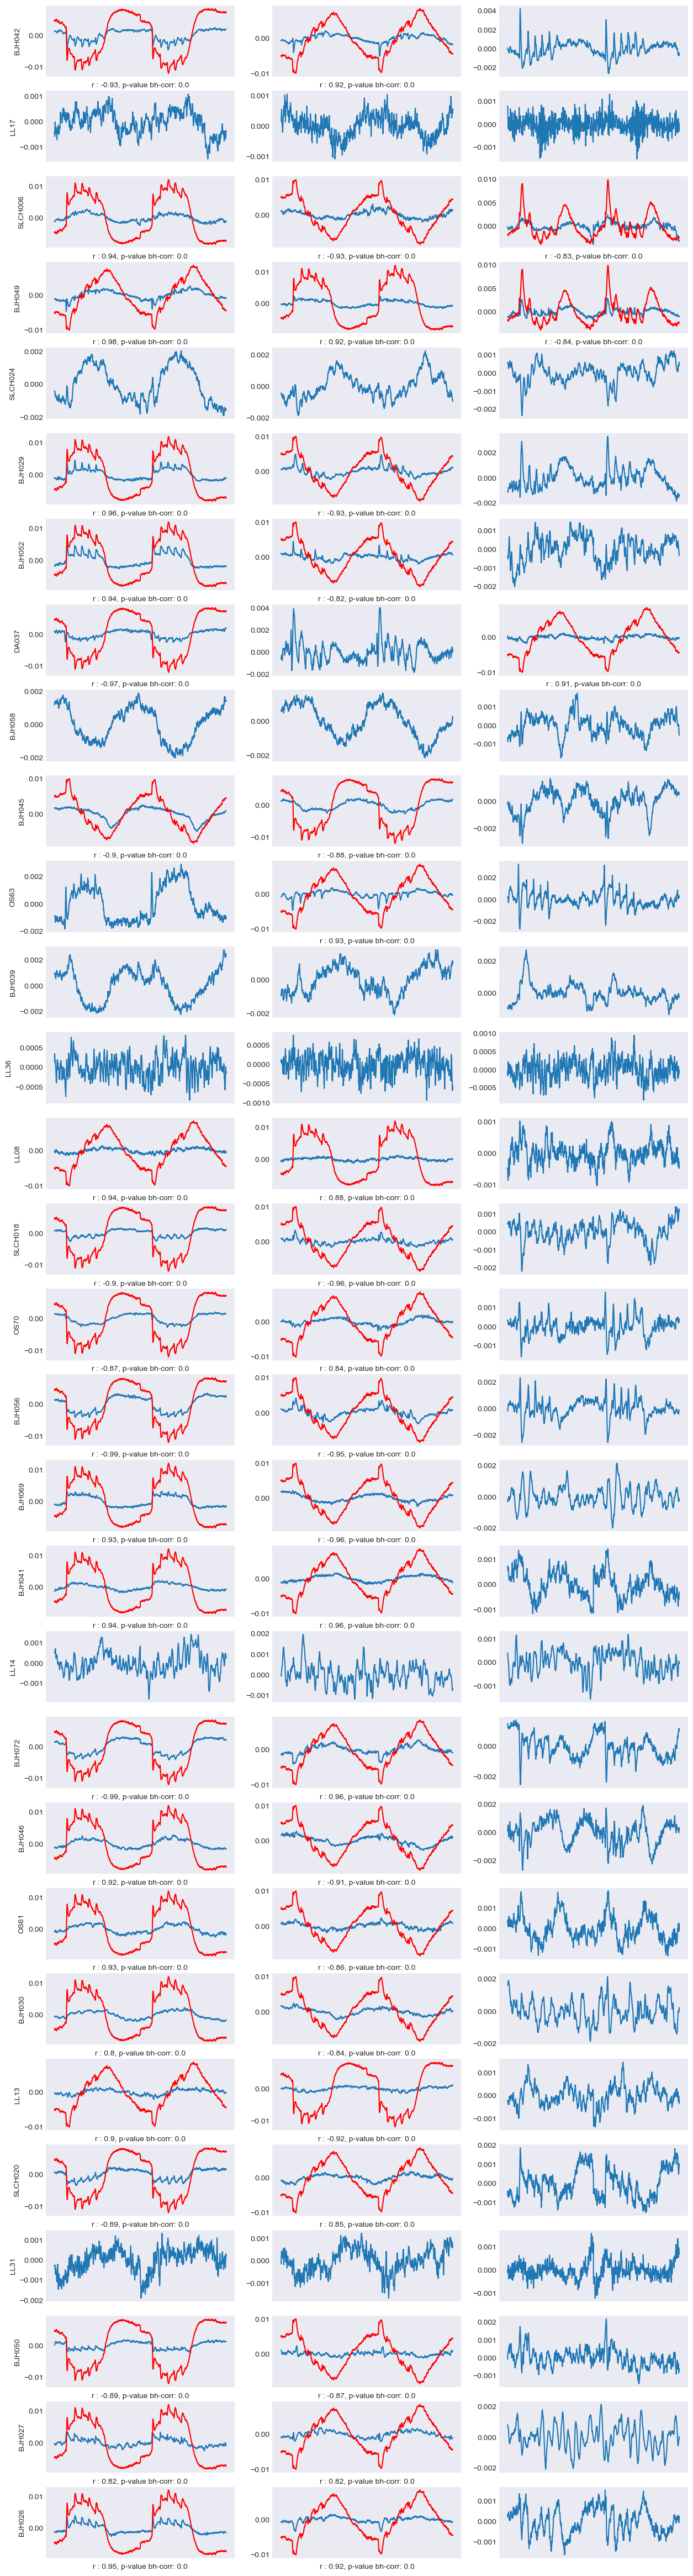

In [172]:
fig, ax = plt.subplots(len(subj_included),nb_compo, figsize = (15, len(subj_included)*2))
compo1 = 0
compo2 = 0
compo3 = 0
for subj_i, subj in enumerate(subj_included) : 
    subj_df = subj_TS.query('subj == @subj') 
    for j in range(nb_compo) : 
        ax[subj_i][j].plot(subj_df.set_index('compo').loc[f'compo{j+1}', :index_col].values)
        ax[subj_i][j].set_xticklabels([])

    data1 = grp_TS.drop(columns = ['subj', 'freq', 'compo']).values.T
    data2 = subj_df.drop(columns = ['subj', 'freq', 'compo']).values.T
    data1 = gaussian_filter1d(data1.T, sigma=20).T
    data2 = gaussian_filter1d(data2.T, sigma=20).T

    R = np.zeros((data1.shape[1], data2.shape[1]))
    P = np.zeros((data1.shape[1], data2.shape[1]))

    for i in range(data1.shape[1]):
        for j in range(data2.shape[1]):
            r, pval = spearmanr(data1[:, i], data2[:, j])
            R[i, j] = r
            P[i, j] = pval

    P_corr = P * 9 # Bonferroni correction for 3x3 tests

    xcor, ycor = np.where(R > 0.8)
    for x, y in zip(xcor, ycor) :
        if x == 0 : 
            compo1 += 1
        elif x == 1 :
            compo2 += 1
        elif x ==2 :
            compo3 += 1
        ax[subj_i][y].plot(grp_TS.set_index('compo').loc['compo' + str(x+1), :index_col].values, color = 'red')
        ax[subj_i][y].set_xlabel(f'r : {np.round(R[x, y], 2)}, p-value bh-corr: {P_corr[x, y]}')
    
    xcor, ycor = np.where(R < - 0.8)
    for x, y in zip(xcor, ycor) :
        if x == 0 : 
            compo1 += 1
        elif x == 1 :
            compo2 += 1
        elif x ==2 :
            compo3 += 1
        ax[subj_i][y].plot(- grp_TS.set_index('compo').loc['compo' + str(x+1), :index_col].values, color = 'red')
        ax[subj_i][y].set_xlabel(f'r : {np.round(R[x, y], 2)}, p-value bh-corr: {P_corr[x, y]}')

    ax[subj_i][0].set_ylabel(subj) 
    

In [173]:
compo1, compo2, compo3

(22, 23, 2)

In [178]:
# subj compo weights distribution vs grp compo weights distribution
nb_compo =3
list_compo = []
subj_list = []
concat_data_list = []

for subj in subj_included : 
    epochs = BbEvents(subj, data_path=epoch_path)
    #data= epochs.mean(0)
    data = np.concat([epochs[0, :, :], epochs[1, :, :]], axis = 1)
    concat_data_list.append(epochs)
    pca = PCA(nb_compo)
    pca.fit(data.T)

    list_compo.append(pca.components_)
    subj_list.append([subj] * pca.components_.shape[1])

data_grp = np.hstack(concat_data_list)
#data_grp_ = data_grp.mean(0)
data_grp_ = np.concat([data_grp[i, :, :] for i in [0, 1]], axis =1)

pca = PCA(nb_compo)
pca.fit(data_grp_.T)

grp_compo = pca.components_
subj_compo = np.concat(list_compo, axis=1)

Text(0.5, 1.0, 'Spearman correlation between subject and group component weights')

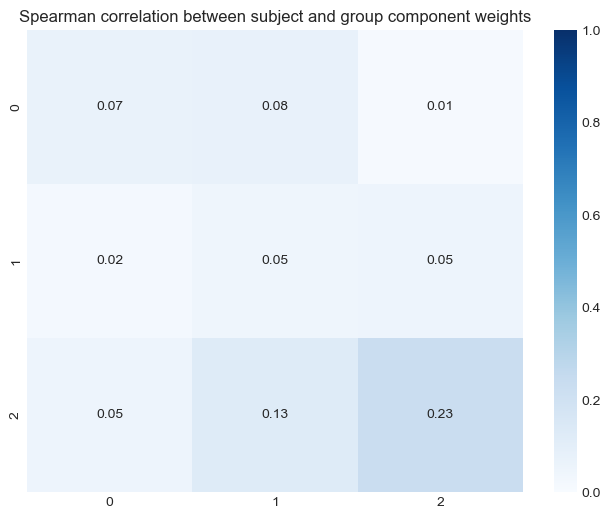

In [179]:
R = np.zeros((grp_compo.shape[0], subj_compo.shape[0]))
P = np.zeros((grp_compo.shape[0], subj_compo.shape[0]))

for i in range(grp_compo.shape[0]):
    for j in range(subj_compo.shape[0]):
        r, pval = spearmanr(grp_compo[i, :], subj_compo[j, :])
        R[i, j] = r
        P[i, j] = pval

fig, ax = plt.subplots(figsize = (8, 6))
sns.heatmap(abs(R), vmin=0, vmax=1, cmap='Blues', ax=ax, annot=True , fmt='.2f')
ax.set_title('Spearman correlation between subject and group component weights')